In [1]:
import argparse
import os
import re

import torch.nn.functional as F

os.environ["TORCHINDUCTOR_DISABLE"] = "1"
os.environ["TORCH_COMPILE"] = "0"
os.environ["TORCHDYNAMO_DISABLE"] = "1"
os.environ["DISABLE_TORCH_COMPILE"] = "1"
os.environ["TRANSFORMERS_NO_COMPILE"] = "1"
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from safetensors.torch import load_file as load_safetensors
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (adjusted_rand_score, balanced_accuracy_score,
                             calinski_harabasz_score, classification_report,
                             davies_bouldin_score, pairwise_distances,
                             silhouette_score)
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
import umap
import glob
from scipy.stats import spearmanr


/home/fe/purelku/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/home/fe/purelku/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
models = [ "google/gemma-2-2b-it", "meta-llama/Llama-3.2-3B-Instruct", "google/gemma-2-2b", "meta-llama/Llama-3.2-3B",
           "Qwen/Qwen2.5-3B", "Qwen/Qwen2.5-3B-Instruct", "allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct"]


output_dir = "/data/erblina/Master_thesis"

datasets_list = ["walledai/AdvBench","walledai/DTStereotype", "walledai/CatHarmfulQA","walledai/DTToxicity","truthfulqa/truthful_qa"]


model_steering_1 = {'Qwen/Qwen2.5-3B': {'layers': [ 'model.layers.19', 'model.layers.20', 'model.layers.22'], 'alphas_up': [ 1.6, 1.6, 1.6], 'alphas_down': [ -1.8, -2.0, -2.0], 'max_avg_tox': [0.87, 0.87, 0.795, 0.76], 'min_avg_tox': [0.21, 0.21, 0.22, 0.19]},
    'Qwen/Qwen2.5-3B-Instruct': {'layers': [ 'model.layers.21', 'model.layers.20', 'model.layers.22'], 'alphas_up': [ 2.0, 2.0, 2.0], 'alphas_down': [ -0.6, -0.6, -0.6], 'max_avg_tox': [0.79, 0.79, 0.785, 0.78], 'min_avg_tox': [0.0, 0.0, 0.0, 0.0]},
    'allenai/OLMo-2-0425-1B-Instruct': {'layers': [ 'model.layers.9', 'model.layers.7', 'model.layers.8'], 'alphas_up': [ 2.0, 1.8, 1.6], 'alphas_down': [ -0.8, -1.0, -0.8], 'max_avg_tox': [0.75, 0.75, 0.735, 0.715], 'min_avg_tox': [0.0, 0.0, 0.0, 0.0]},
    'allenai/OLMo-2-0425-1B': {'layers': ['model.layers.5', 'model.layers.7', 'model.layers.4'], 'alphas_up': [-0.15, -0.07, 0.05], 'alphas_down': [-2.0, -1.5, -2.0], 'max_avg_tox': [0.4, 0.39, 0.39], 'min_avg_tox': [0.09, 0.085, 0.09]},
    'google/gemma-2-2b-it': {'layers': [ 'model.layers.10', 'model.layers.11', 'model.layers.12'], 'alphas_up': [ 1.5, 1.1, 1.0], 'alphas_down': [-0.3, -0.25, -0.2], 'max_avg_tox': [0.63, 0.63, 0.615, 0.595], 'min_avg_tox': [0.0, 0.0, 0.0, 0.0]},
    'meta-llama/Llama-3.2-3B-Instruct': {'layers': [ 'model.layers.12', 'model.layers.13', 'model.layers.14'], 'alphas_up': [ 2.0, 1.6, 2.0], 'alphas_down': [ -0.8, -0.5, -0.5], 'max_avg_tox': [0.82, 0.82, 0.81, 0.79], 'min_avg_tox': [0.0, 0.0, 0.0, 0.0]},
    'google/gemma-2-2b': {'layers': [ 'model.layers.6', 'model.layers.7', 'model.layers.13'], 'alphas_up': [ 1.2, 1.3, 1.4], 'alphas_down': [ -2.0, -1.8, -1.8], 'max_avg_tox': [0.36, 0.36, 0.35, 0.36], 'min_avg_tox': [0.135, 0.02, 0.035, 0.065]},
    'meta-llama/Llama-3.2-3B': {'layers': [ 'model.layers.12', 'model.layers.10', 'model.layers.11'], 'alphas_up': [ 0.7, 1.0, 1.0], 'alphas_down': [ -2.0, -1.4, -1.6], 'max_avg_tox': [0.605, 0.57, 0.575, 0.6], 'min_avg_tox': [0.385, 0.3, 0.33, 0.36]},
        }

In [3]:
def load_harmbench(model, output_dir):
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)

    ###### HARMBENCH DATASET ######
    labels = np.load(f"{output_dir}/{safe_model_name}/labels.npy")
    hidden_states = load_safetensors(
        os.path.join(f"{output_dir}/{safe_model_name}", f"hidden_states_pure.safetensors"))
    
    side = 'toxic'
    # # Define path pattern
    # pattern = f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_*.npy"

    # # Find all matching files
    # files = sorted(glob.glob(pattern))

    # # Load them into a dictionary keyed by alpha
    # data = {}
    # for file in files:
    #     # Extract the alpha value from filename
    #     alpha_str = os.path.splitext(os.path.basename(file))[0].split('_alpha_')[-1]
    #     alpha = float(alpha_str)
    #     data[alpha] = np.load(file, allow_pickle=True).item()

    return hidden_states, labels #, data

def load_datasets(model, dataset, output_dir):
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)

    safe_dataset = re.sub(r'[\\/*?:"<>|]', "_", dataset)
    hidden_states_data = load_safetensors(os.path.join(output_dir, safe_model_name, f"{safe_dataset}_hidden_states_pure.safetensors"))
    labels_data = np.load(f"{output_dir}/{safe_model_name}/labels_{safe_dataset}.npy")

    return hidden_states_data, labels_data

def load_steering_dataset(model, dataset, model_steering_1, output_dir):
    side = 'toxic'
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
    safe_dataset = re.sub(r'[\\/*?:"<>|]', "_", dataset)
        # Find the layer corresponding to the given alpha
    layers = model_steering_1[model]['layers']
    data = {}
    for layer in layers:
        alpha = model_steering_1[model]['alphas_up'][layers.index(layer)] # or alphas_down
        labels_after_dataset = np.load(
                f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_{alpha}_{safe_dataset}_{layer}.npy", allow_pickle=True).item()[layer]

        alpha_d = model_steering_1[model]['alphas_down'][layers.index(layer)]
        labels_after_dataset_d = np.load(
                f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_{alpha_d}_{safe_dataset}_{layer}.npy", allow_pickle=True).item()[layer]

        data[layer] = {
            alpha : labels_after_dataset,
            alpha_d : labels_after_dataset_d
        }

    return data

def load_steering_harmbench(model, model_steering_1, output_dir):
    side = 'toxic'
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
        # Find the layer corresponding to the given alpha
    layers = model_steering_1[model]['layers']
    data = {}
    for layer in layers:
        alpha = model_steering_1[model]['alphas_up'][layers.index(layer)] # or alphas_down
        labels_after = np.load(
                f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_{alpha}_{layer}.npy", allow_pickle=True).item()[layer]

        alpha_d = model_steering_1[model]['alphas_down'][layers.index(layer)]
        labels_after_d = np.load(
                f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_{alpha_d}_{layer}.npy", allow_pickle=True).item()[layer]

        data[layer] = {
            alpha : labels_after,
            alpha_d : labels_after_d
        }

    return data


In [4]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.pyplot as plt
import numpy as np

from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, NeighborhoodComponentsAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap  # <-- add this import


def plot_dim_reduction_comparison(X, y):
    n_neighbors = 5
    random_state = 0

    X_c = np.concatenate(X, axis=0)
    y_c = np.concatenate(y, axis=0)

    # Split into train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X_c, y_c, test_size=0.5, stratify=y_c, random_state=random_state
    )

    dim = len(X_c[0])
    n_classes = len(np.unique(y_c))

    # Reduce dimension to 2 with PCA
    pca = make_pipeline(StandardScaler(), PCA(n_components=2, random_state=random_state))

    # Reduce dimension to 2 with LinearDiscriminantAnalysis
    lda = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis(n_components=2))

    # Reduce dimension to 2 with NeighborhoodComponentAnalysis
    nca = make_pipeline(
        StandardScaler(),
        NeighborhoodComponentsAnalysis(n_components=2, random_state=random_state),
    )

    # Use a nearest neighbor classifier to evaluate the methods
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)

    # Make a list of the methods to be compared
    dim_reduction_methods = [("PCA", pca), ("NCA", nca)] #("LDA", lda)] #, 
    c = plt.cm.get_cmap("Set1", len(X))
    # plt.figure()
    for i, (name, model) in enumerate(dim_reduction_methods):
        plt.figure()
        # plt.subplot(1, 3, i + 1, aspect=1)

        # Fit the method's model
        model.fit(X_train, y_train)

        # Fit a nearest neighbor classifier on the embedded training set
        knn.fit(model.transform(X_train), y_train)

        # Compute the nearest neighbor accuracy on the embedded test set
        acc_knn = knn.score(model.transform(X_test), y_test)

        for i, (X_, y_) in enumerate(zip(X, y)):
            # Embed the data set in 2 dimensions using the fitted model
            X_embedded = model.transform(X_)

            # Plot the projected points and show the evaluation score
            plt.scatter(X_embedded[:, 0][y_ == 0], X_embedded[:, 1][y_ == 0], c=c(i), s=30, alpha=0.3, marker='o', zorder=1)

            plt.scatter(X_embedded[:, 0][y_ == 1], X_embedded[:, 1][y_ == 1], c=c(i), s=80, alpha=0.7, marker='x', zorder=1)

        plt.title(
            "{}, KNN (k={})\nTest accuracy = {:.2f}".format(name, n_neighbors, acc_knn)
        )
    plt.show()
    plt.close()


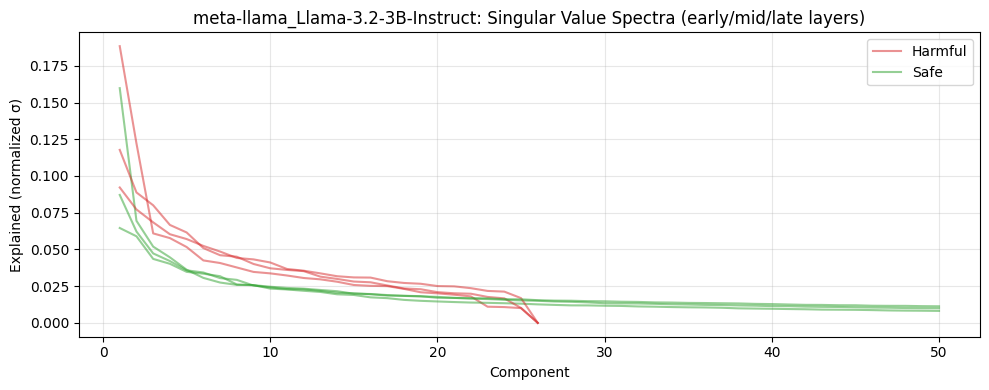

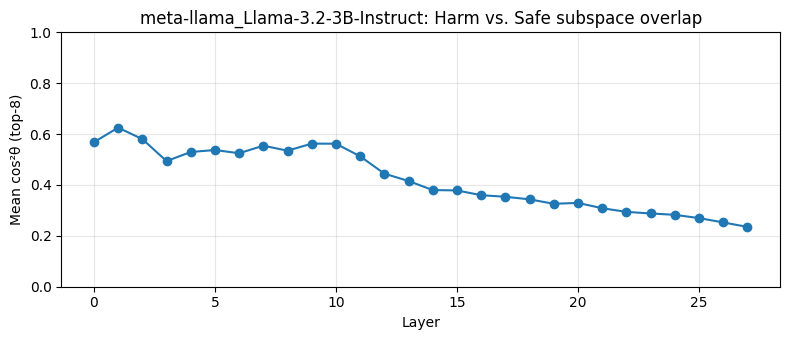

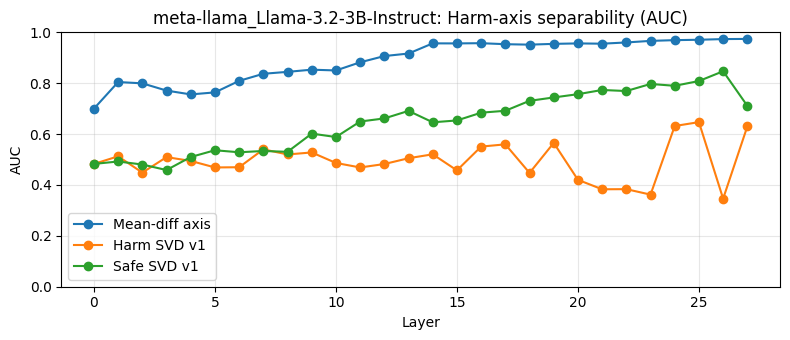

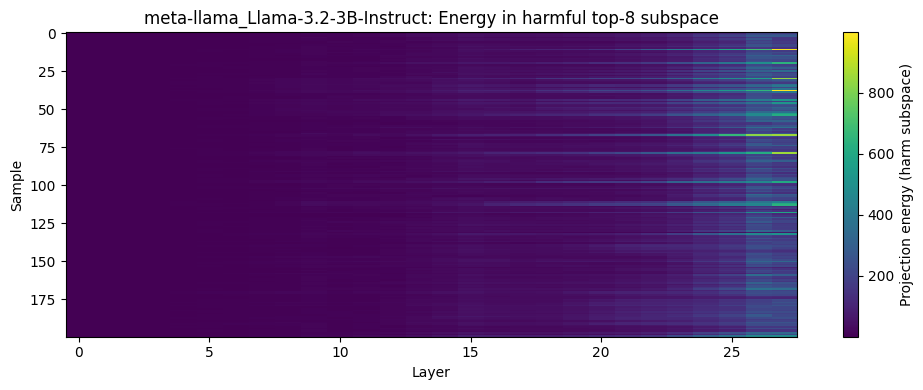

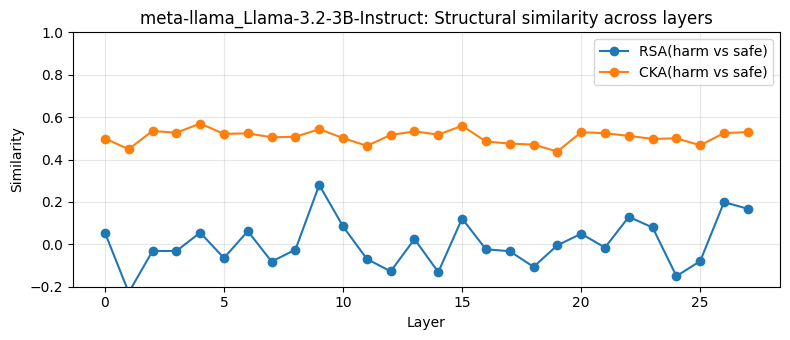

/tmp/ipykernel_171638/3762252449.py:345: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data, labels=labels, patch_artist=True, widths=0.35, showfliers=False, showmeans=True)


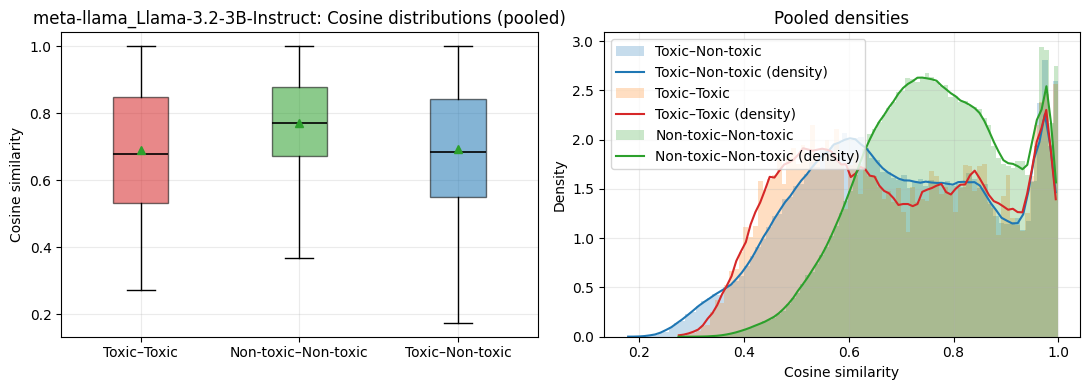

[Saved] Geometry plots for meta-llama_Llama-3.2-3B-Instruct -> /home/fe/purelku/Desktop/Master_thesis/geometry_plots/meta-llama_Llama-3.2-3B-Instruct


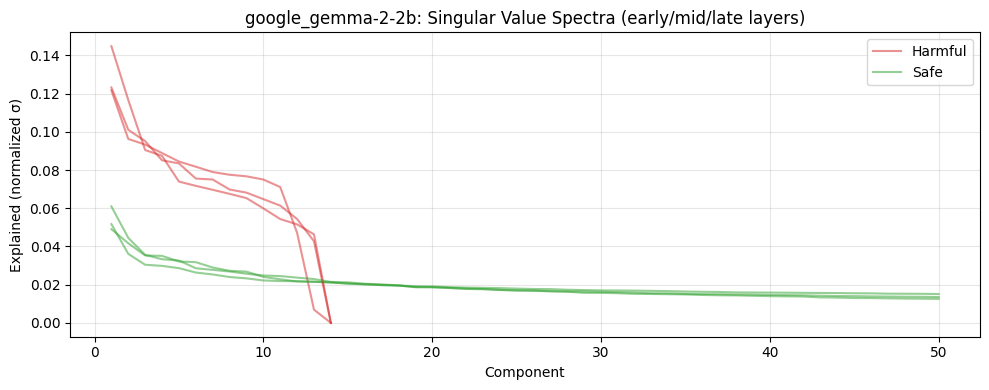

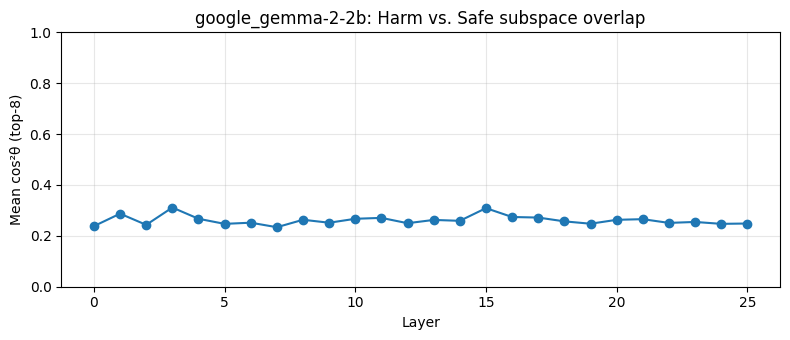

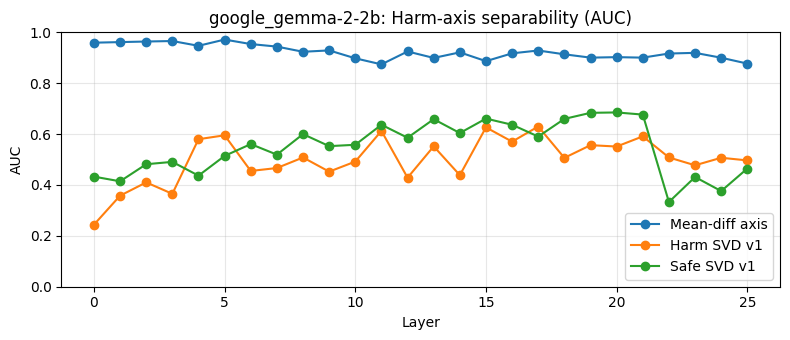

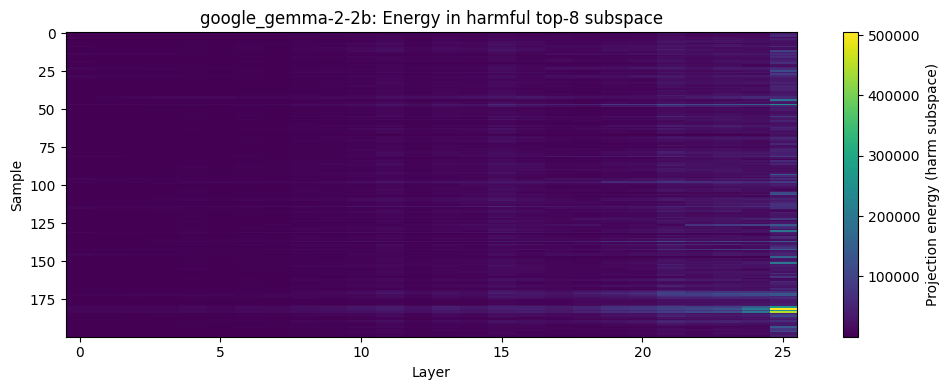

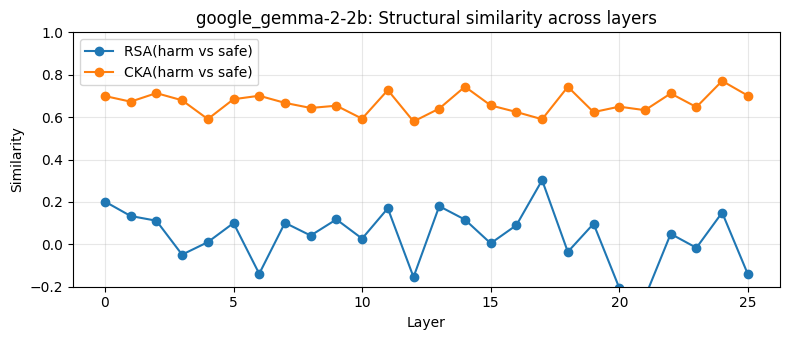

/tmp/ipykernel_171638/3762252449.py:345: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data, labels=labels, patch_artist=True, widths=0.35, showfliers=False, showmeans=True)


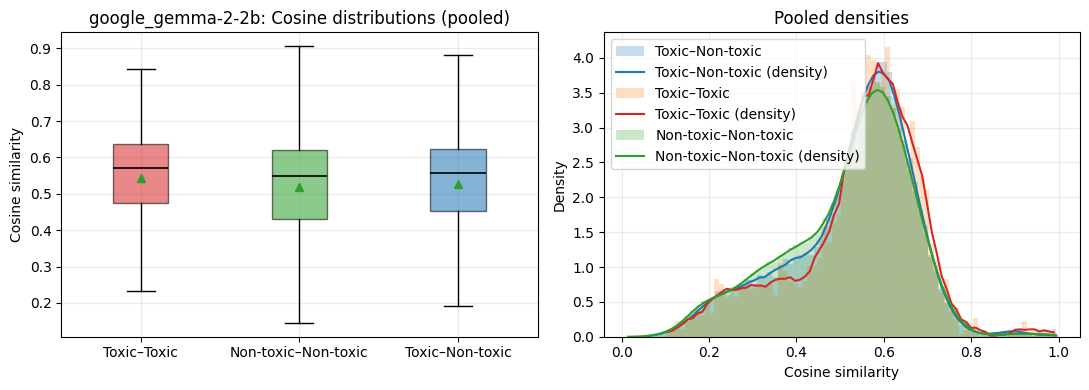

[Saved] Geometry plots for google_gemma-2-2b -> /home/fe/purelku/Desktop/Master_thesis/geometry_plots/google_gemma-2-2b


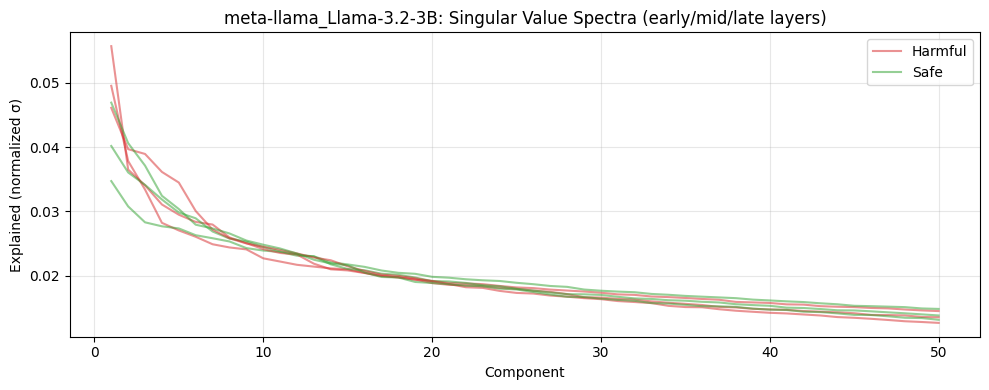

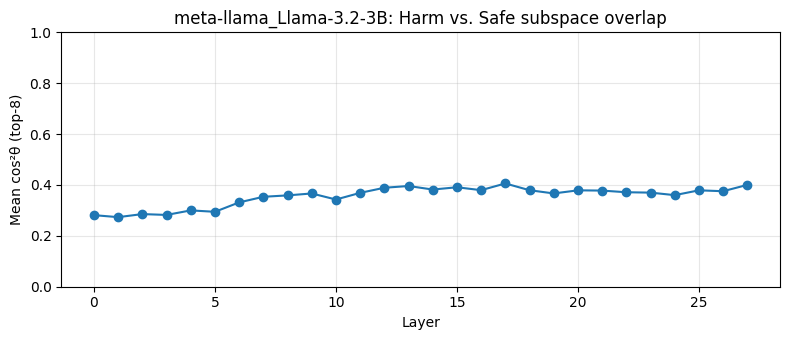

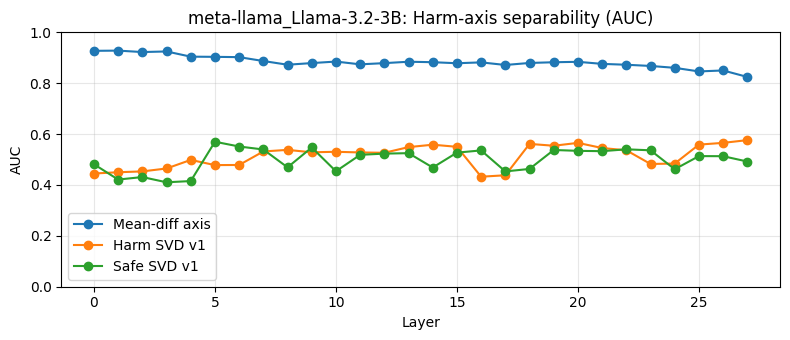

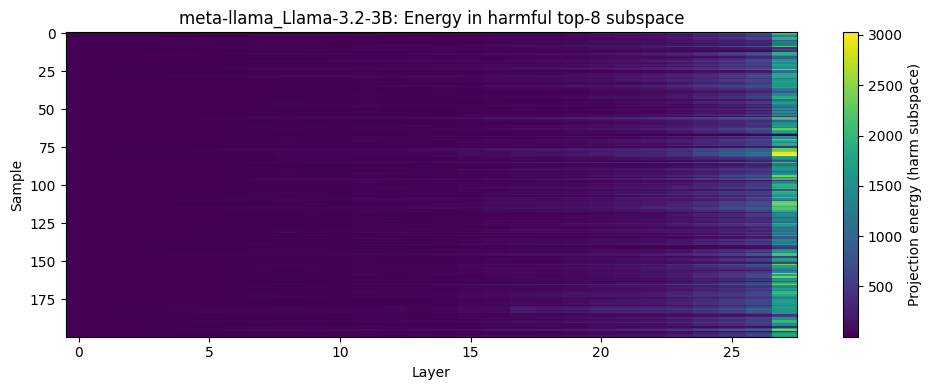

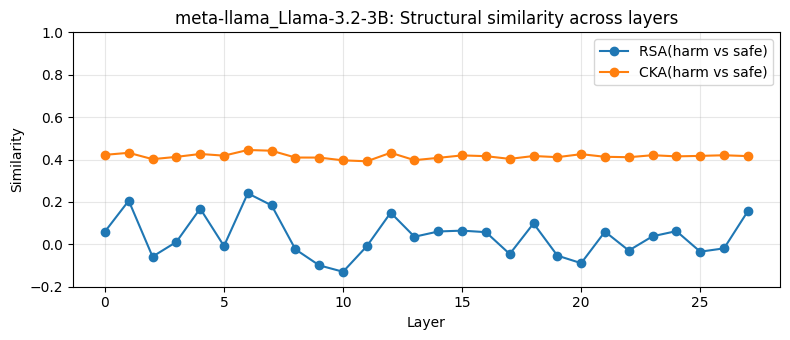

/tmp/ipykernel_171638/3762252449.py:345: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data, labels=labels, patch_artist=True, widths=0.35, showfliers=False, showmeans=True)


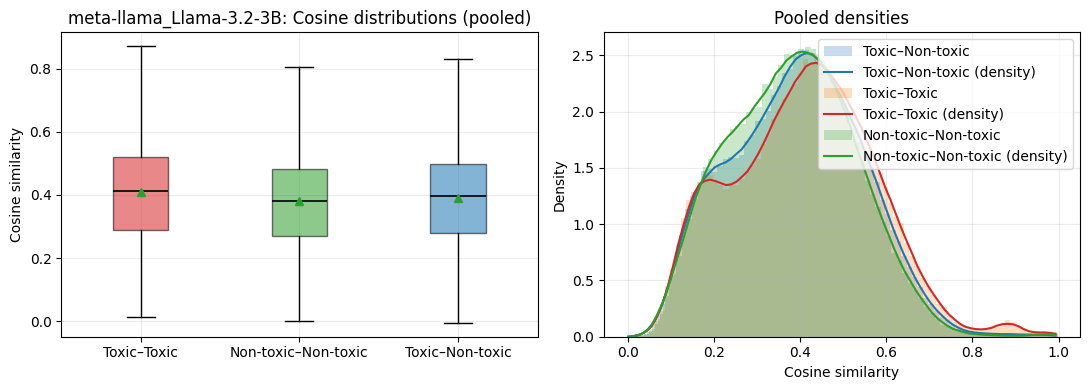

[Saved] Geometry plots for meta-llama_Llama-3.2-3B -> /home/fe/purelku/Desktop/Master_thesis/geometry_plots/meta-llama_Llama-3.2-3B


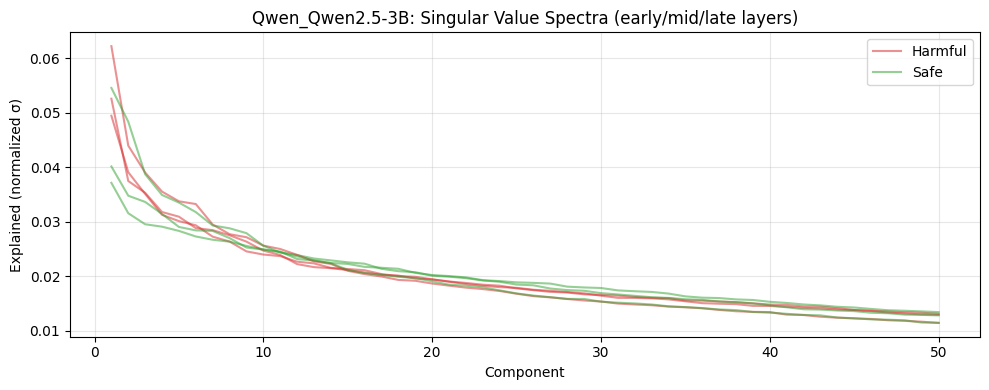

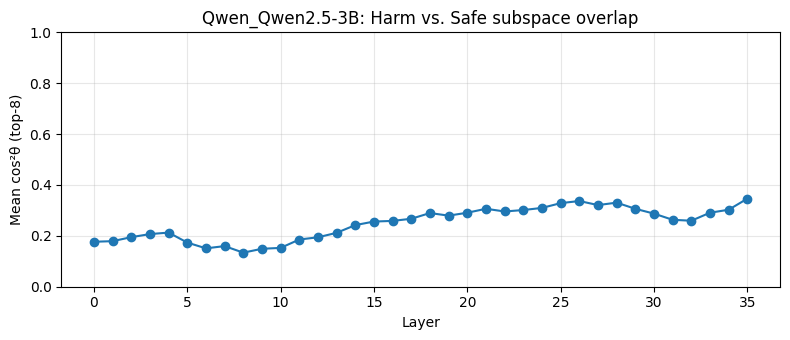

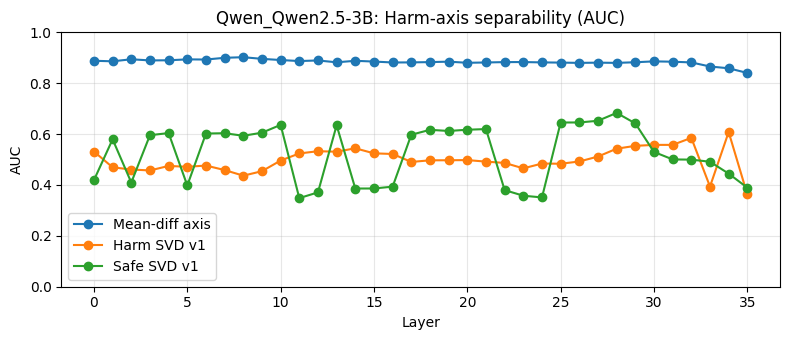

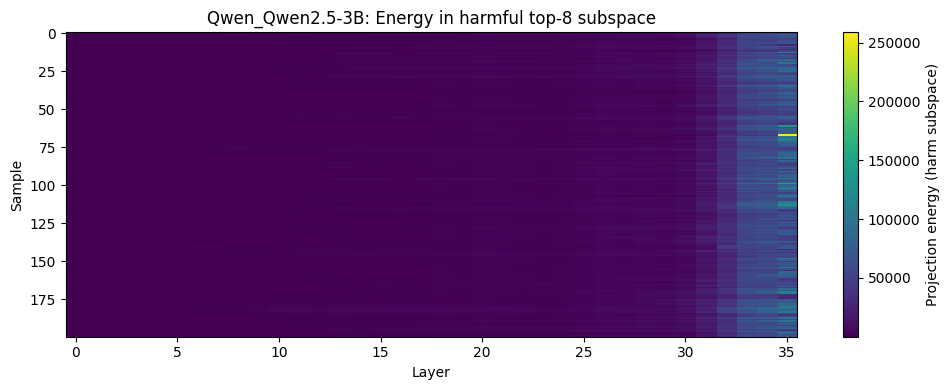

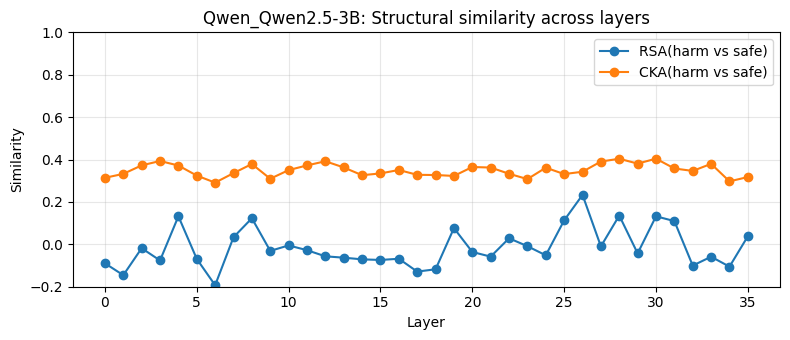

/tmp/ipykernel_171638/3762252449.py:345: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data, labels=labels, patch_artist=True, widths=0.35, showfliers=False, showmeans=True)


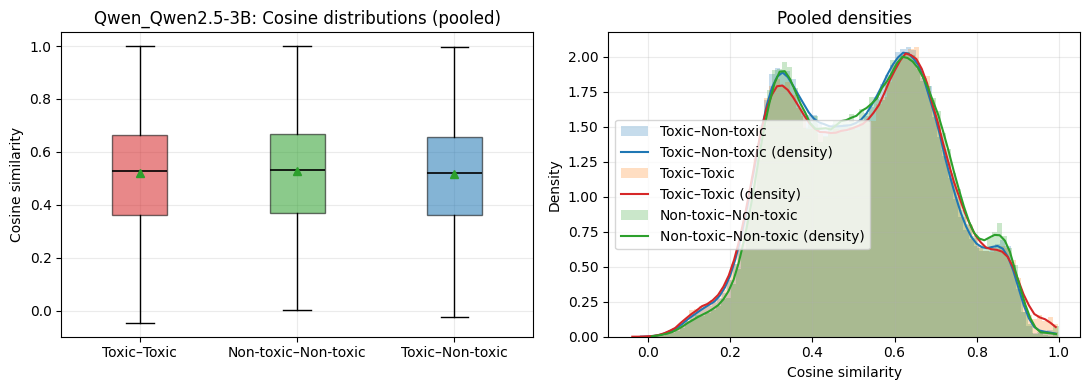

[Saved] Geometry plots for Qwen_Qwen2.5-3B -> /home/fe/purelku/Desktop/Master_thesis/geometry_plots/Qwen_Qwen2.5-3B


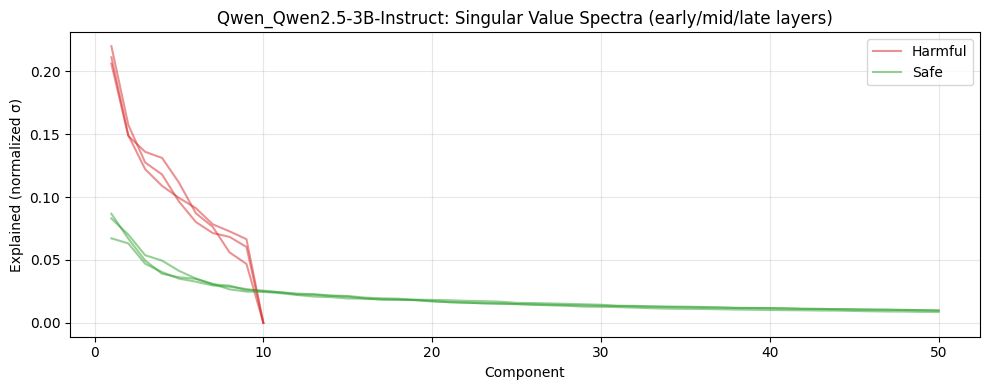

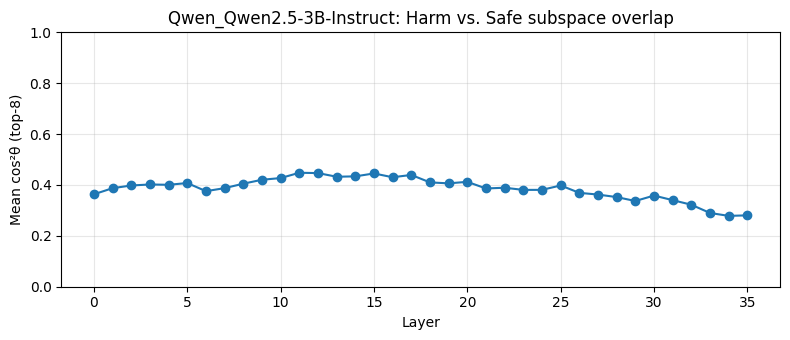

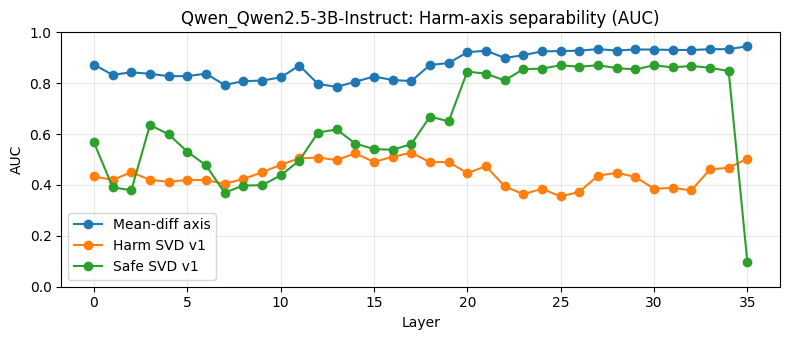

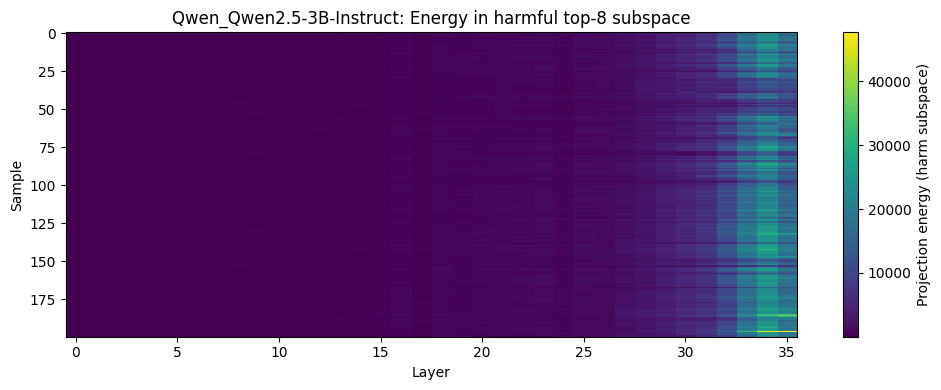

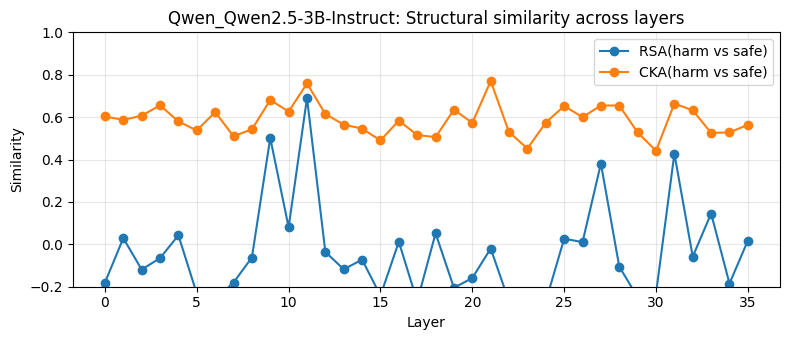

/tmp/ipykernel_171638/3762252449.py:345: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data, labels=labels, patch_artist=True, widths=0.35, showfliers=False, showmeans=True)


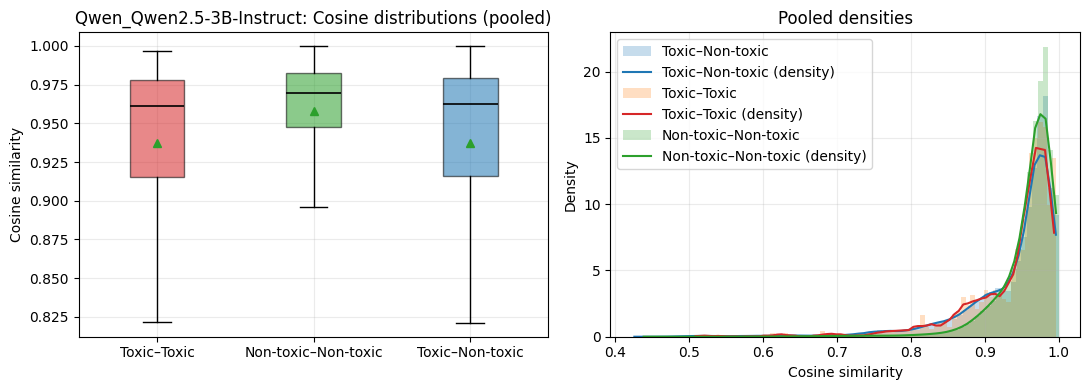

[Saved] Geometry plots for Qwen_Qwen2.5-3B-Instruct -> /home/fe/purelku/Desktop/Master_thesis/geometry_plots/Qwen_Qwen2.5-3B-Instruct


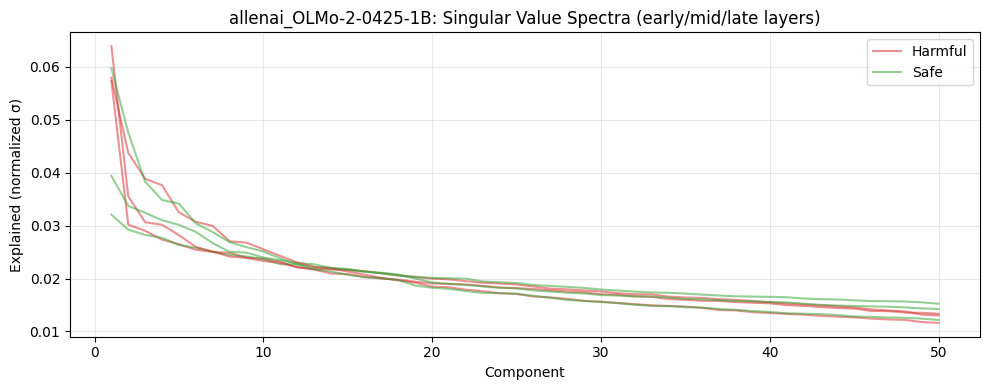

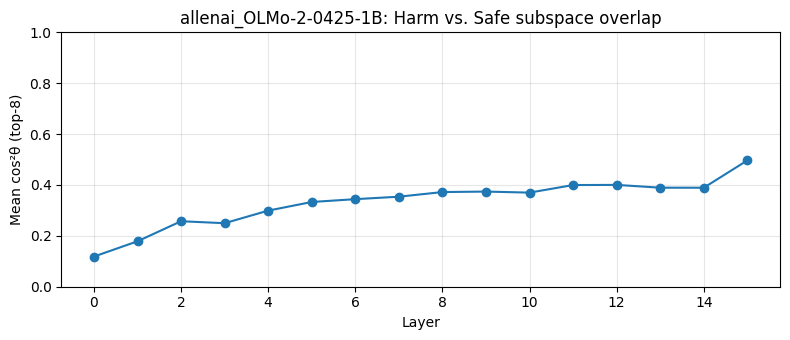

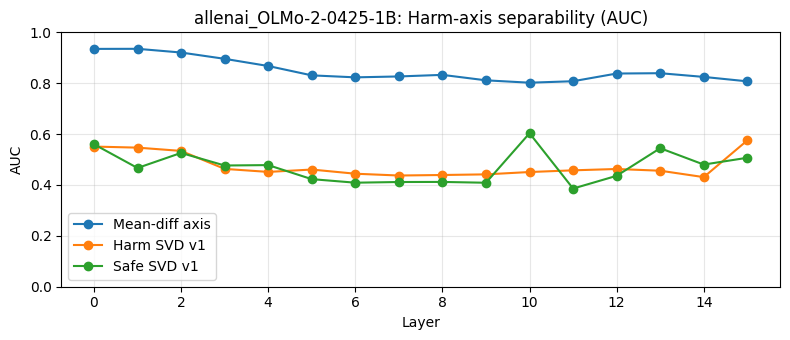

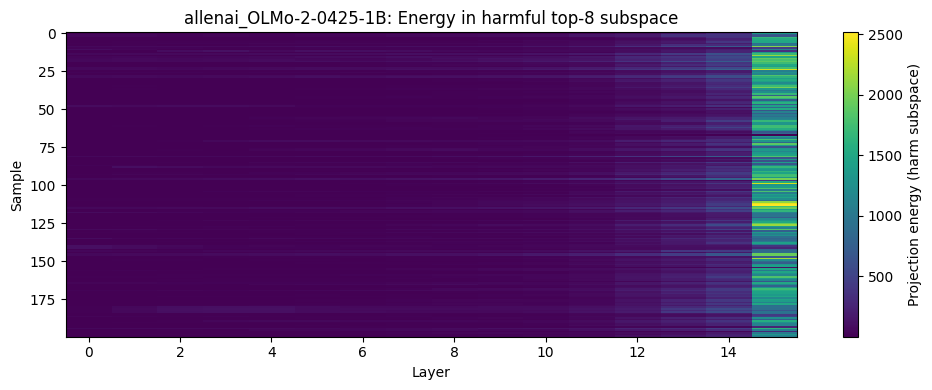

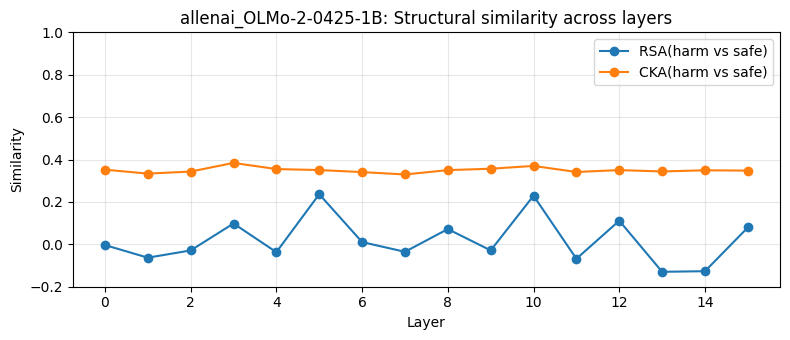

/tmp/ipykernel_171638/3762252449.py:345: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data, labels=labels, patch_artist=True, widths=0.35, showfliers=False, showmeans=True)


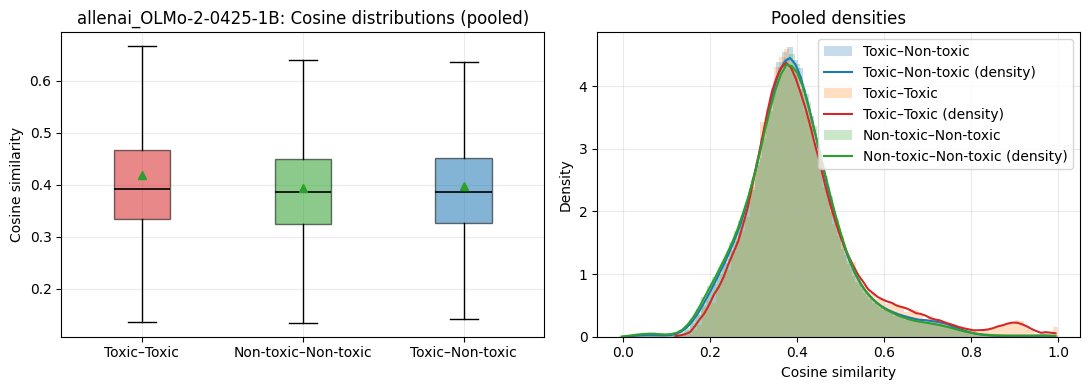

[Saved] Geometry plots for allenai_OLMo-2-0425-1B -> /home/fe/purelku/Desktop/Master_thesis/geometry_plots/allenai_OLMo-2-0425-1B


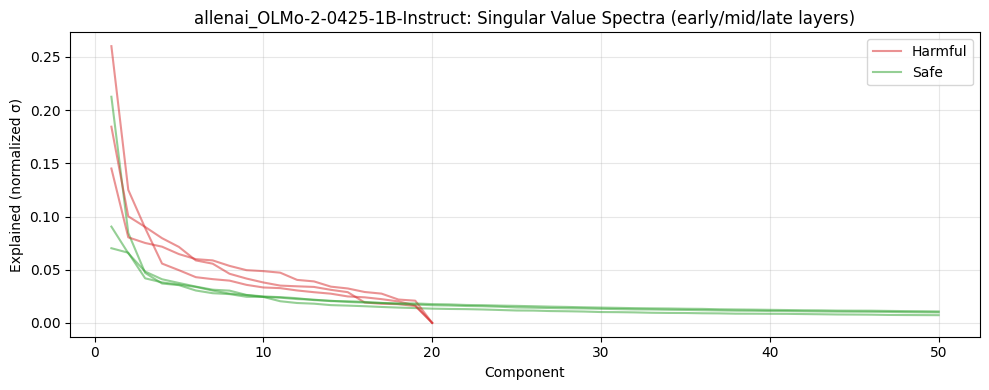

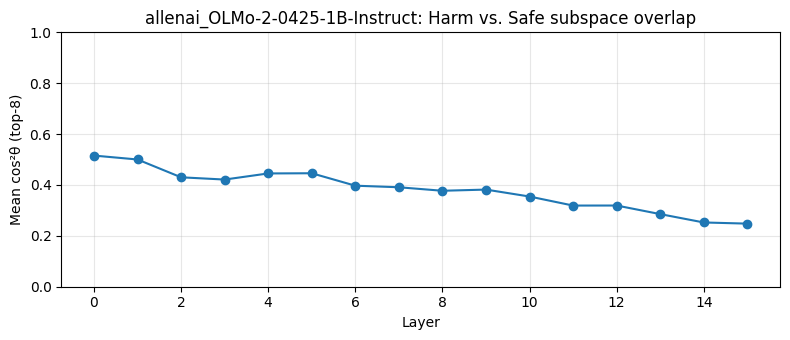

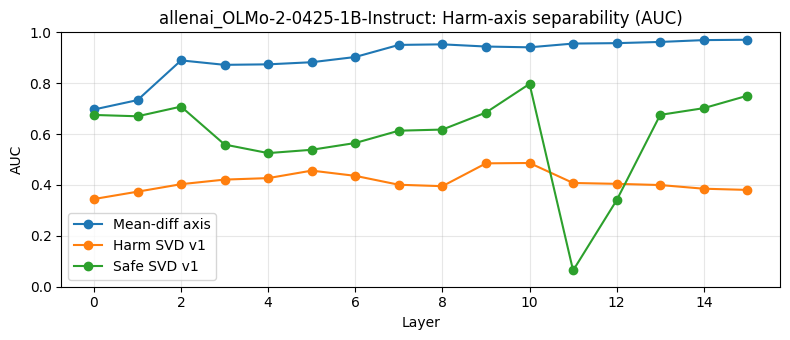

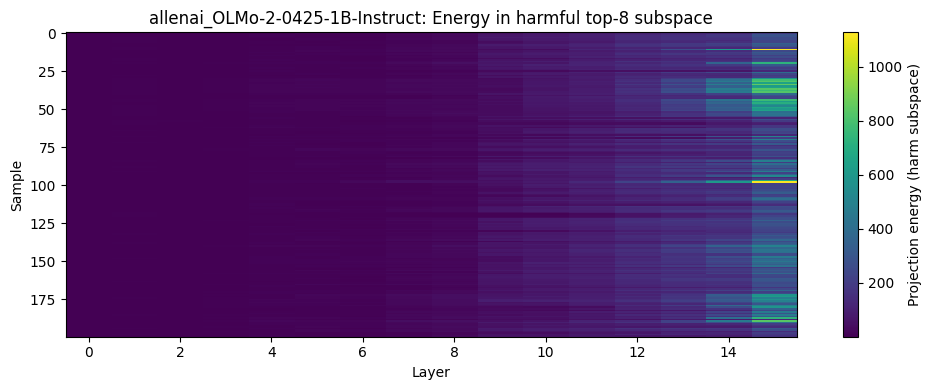

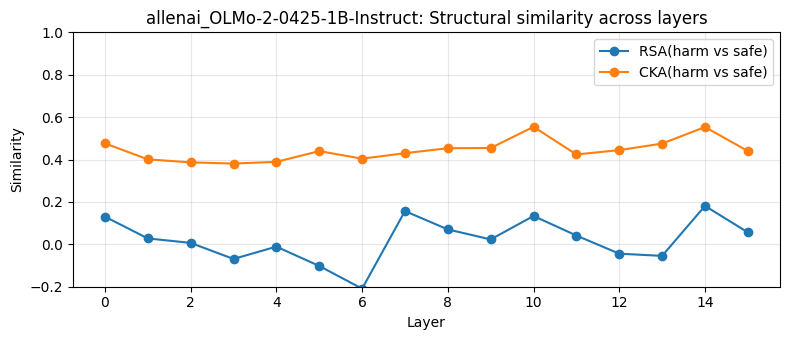

/tmp/ipykernel_171638/3762252449.py:345: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data, labels=labels, patch_artist=True, widths=0.35, showfliers=False, showmeans=True)


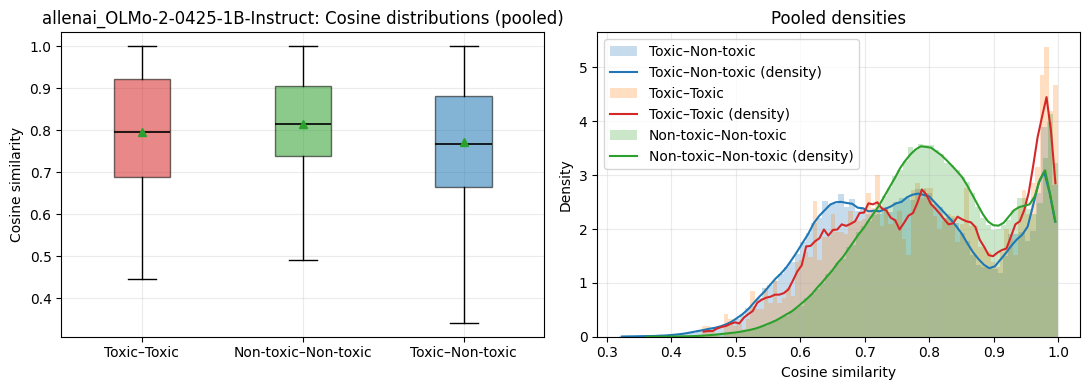

[Saved] Geometry plots for allenai_OLMo-2-0425-1B-Instruct -> /home/fe/purelku/Desktop/Master_thesis/geometry_plots/allenai_OLMo-2-0425-1B-Instruct


In [61]:
import os, re
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr

# =========================
# Helper functions
# =========================
def to_numpy(x):
    if hasattr(x, "detach"):
        return x.detach().cpu().float().numpy()
    return np.asarray(x, dtype=np.float32)

def l2_normalize_rows(X, eps=1e-8):
    n = np.linalg.norm(X, axis=1, keepdims=True)
    return X / (n + eps)

def upper_triangle(mat):
    if mat.size == 0:
        return np.array([])
    i, j = np.triu_indices_from(mat, k=1)
    return mat[i, j]

def participation_ratio_from_svals(s):
    # s: singular values (1D)
    s2 = np.sum(s)**2
    s_sq_sum = np.sum(s**2) + 1e-12
    return s2 / s_sq_sum

def principal_angle_similarity(A, B, k):
    """
    A, B: (d x r) right-singular-vector matrices (or any orthonormal bases).
    Returns mean cos^2(theta_i) for the top-k subspaces.
    """
    Ak = A[:, :k]
    Bk = B[:, :k]
    U, s, Vt = np.linalg.svd(Ak.T @ Bk, full_matrices=False)
    return float(np.mean(s**2))  # average cos^2 theta

def rdm_from_X(X):
    # cosine dissimilarity matrix: 1 - cosine_similarity
    return 1.0 - cosine_similarity(X)

def rsa_upper(R1, R2):
    i, j = np.triu_indices_from(R1, k=1)
    return spearmanr(R1[i, j], R2[i, j], nan_policy='omit')[0]

def cka_linear(X, Y):
    Xc = X - X.mean(0, keepdims=True)
    Yc = Y - Y.mean(0, keepdims=True)
    Kx = Xc @ Xc.T
    Ky = Yc @ Yc.T
    num = np.sum(Kx * Ky)
    den = np.sqrt(np.sum(Kx*Kx) * np.sum(Ky*Ky)) + 1e-12
    return float(num / den)

def mean_diff_axis(Xh, Xs):
    w = Xh.mean(0) - Xs.mean(0)
    n = np.linalg.norm(w) + 1e-12
    return w / n

def top_right_singular_vector(X):
    # returns first right singular vector v1, shape (d,)
    Xc = X - X.mean(0, keepdims=True)
    U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
    v1 = Vt[0]
    return v1 / (np.linalg.norm(v1) + 1e-12)

def projection_energy(X, B):  # B: (d x k) basis
    Z = X @ B                 # (n x k)
    return np.sum(Z**2, axis=1)

def maybe_kde(ax, arr, label, color):
    arr = np.asarray(arr).ravel()
    if arr.size > 1 and np.isfinite(arr).all() and (np.std(arr) > 1e-8):
        # Use plain matplotlib hist + density=True to avoid seaborn dependency
        ax.hist(arr, bins=80, density=True, alpha=0.25, label=label)
        ax.plot(*_density_curve(arr), color=color, lw=1.5, label=f"{label} (density)")
    else:
        ax.hist(arr, bins=40, density=True, alpha=0.25, label=label)

def _density_curve(x):
    # simple kernel density via numpy histogram smoothing (no seaborn)
    hist, edges = np.histogram(x, bins=80, density=True)
    ctrs = 0.5 * (edges[:-1] + edges[1:])
    # moving average smoothing
    if len(hist) >= 5:
        kernel = np.ones(5) / 5.0
        hist = np.convolve(hist, kernel, mode='same')
    return ctrs, hist

rng = np.random.default_rng(42)

def balanced_subset(X, y, cap=None):
    """Return equal-size subsets Xh_eq, Xs_eq where size = min(n_h, n_s, cap)."""
    Xh = X[y == 1]; Xs = X[y == 0]
    n = min(len(Xh), len(Xs))
    if cap is not None:
        n = min(n, cap)
    ih = rng.choice(len(Xh), n, replace=False)
    is_ = rng.choice(len(Xs), n, replace=False)
    return Xh[ih], Xs[is_]

def cka_linear_feature_space(X, Y):
    """
    CKA that compares feature covariances: ||XᵀY||_F² / (||XᵀX||_F · ||YᵀY||_F).
    Works for different number of rows in X and Y.
    """
    Xc = X - X.mean(0, keepdims=True)
    Yc = Y - Y.mean(0, keepdims=True)
    num = np.linalg.norm(Xc.T @ Yc, 'fro')**2
    den = (np.linalg.norm(Xc.T @ Xc, 'fro') *
           np.linalg.norm(Yc.T @ Yc, 'fro')) + 1e-12
    return float(num / den)

# =========================
# Main: per model
# =========================
for model in models:

    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
    outdir = f"/home/fe/purelku/Desktop/Master_thesis/geometry_plots/{safe_model_name}"
    os.makedirs(outdir, exist_ok=True)

    # Load HarmBench activations & labels
    X_1, v1 = load_harmbench(model, output_dir)
    layers = sorted(list(X_1.keys()), key=lambda x: int(x.split('.')[-1]))
    y = (to_numpy(v1) > 0).astype(int)

    # Build per-layer containers
    X_list, y_list = [], []
    Xh_list, Xs_list = [], []
    Vh_list, Vs_list = [], []
    PR_h_list, PR_s_list = [], []

    # For cosine distribution pooled across layers, collect per layer separately if needed
    for layer in layers:
        X = l2_normalize_rows(to_numpy(X_1[layer]))
        X = to_numpy(X_1[layer])
        # Keep lists for later plots
        X_list.append(X)
        y_list.append(y)

        Xh = X[y == 1]
        Xs = X[y == 0]

        # Edge cases: ensure at least 2 per class to SVD
        if len(Xh) >= 2:
            Uh, sh, Vh = np.linalg.svd(Xh - Xh.mean(0), full_matrices=False)
            PR_h_list.append(participation_ratio_from_svals(sh))
            Vh_list.append(Vh.T)   # store as (d x r)
        else:
            PR_h_list.append(np.nan)
            Vh_list.append(np.full((X.shape[1], 1), np.nan))

        if len(Xs) >= 2:
            Us, ss, Vs = np.linalg.svd(Xs - Xs.mean(0), full_matrices=False)
            PR_s_list.append(participation_ratio_from_svals(ss))
            Vs_list.append(Vs.T)   # (d x r)
        else:
            PR_s_list.append(np.nan)
            Vs_list.append(np.full((X.shape[1], 1), np.nan))

        Xh_list.append(Xh)
        Xs_list.append(Xs)

    layer_ids = [int(l.split('.')[-1]) for l in layers]

    # -------------------------
    # (1) Singular value spectra: early/mid/late layers
    # -------------------------
    pick_idxs = [0, len(layers)//2, len(layers)-1] if len(layers) >= 3 else list(range(len(layers)))
    plt.figure(figsize=(10, 4))
    for idx, li in enumerate(pick_idxs):
        Xh = Xh_list[li]; Xs = Xs_list[li]
        if len(Xh) >= 2:
            sh = np.linalg.svd(Xh - Xh.mean(0), full_matrices=False, compute_uv=False)
            shn = sh[:50] / (np.sum(sh[:50]) + 1e-12)
            plt.plot(np.arange(1, len(shn)+1), shn, color='tab:red', alpha=0.5, label='Harmful' if idx == 0 else None)
        if len(Xs) >= 2:
            ss = np.linalg.svd(Xs - Xs.mean(0), full_matrices=False, compute_uv=False)
            ssn = ss[:50] / (np.sum(ss[:50]) + 1e-12)
            plt.plot(np.arange(1, len(ssn)+1), ssn, color='tab:green', alpha=0.5, label='Safe' if idx == 0 else None)
    plt.xlabel('Component'); plt.ylabel('Explained (normalized σ)')
    plt.title(f'{safe_model_name}: Singular Value Spectra (early/mid/late layers)')
    plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
    # plt.savefig(f"{outdir}/spectra_overview.png", dpi=300, bbox_inches='tight'); 
    plt.show()
    plt.close()

    # -------------------------
    # (2) Subspace overlap via principal angles (top-k)
    # -------------------------
    top_k = 8
    sim_vals = []
    for Vh, Vs in zip(Vh_list, Vs_list):
        if np.isnan(Vh).any() or np.isnan(Vs).any():
            sim_vals.append(np.nan)
            continue
        k = min(top_k, Vh.shape[1], Vs.shape[1])
        if k < 1:
            sim_vals.append(np.nan)
            continue
        sim_vals.append(principal_angle_similarity(Vh, Vs, k))
    plt.figure(figsize=(8, 3.5))
    plt.plot(layer_ids, sim_vals, marker='o')
    plt.ylim(0, 1); plt.xlabel('Layer'); plt.ylabel(f'Mean cos²θ (top-{top_k})')
    plt.title(f'{safe_model_name}: Harm vs. Safe subspace overlap')
    plt.grid(alpha=0.3); plt.tight_layout()
    # plt.savefig(f"{outdir}/subspace_overlap_top{top_k}.png", dpi=300, bbox_inches='tight'); 
    plt.show()
    plt.close()

    # -------------------------
    # (3) Harm-axis separability (AUC) for 3 axes
    # -------------------------
    auc_md, auc_vh1, auc_vs1 = [], [], []
    for X, y, Xh, Xs in zip(X_list, y_list, Xh_list, Xs_list):
        # skip degenerate cases
        if (y.sum()==0) or (y.sum()==len(y)): 
            auc_md.append(np.nan); auc_vh1.append(np.nan); auc_vs1.append(np.nan); continue

        # mean-difference axis
        if len(Xh) >= 1 and len(Xs) >= 1:
            w_md = mean_diff_axis(Xh, Xs)
            s_md = X @ w_md
            auc_md.append(roc_auc_score(y, s_md))
        else:
            auc_md.append(np.nan)

        # top singular of harmful
        if len(Xh) >= 2:
            v_h1 = top_right_singular_vector(Xh)
            auc_vh1.append(roc_auc_score(y, X @ v_h1))
        else:
            auc_vh1.append(np.nan)

        # top singular of safe
        if len(Xs) >= 2:
            v_s1 = top_right_singular_vector(Xs)
            auc_vs1.append(roc_auc_score(y, X @ v_s1))
        else:
            auc_vs1.append(np.nan)

    plt.figure(figsize=(8, 3.5))
    plt.plot(layer_ids, auc_md,  marker='o', label='Mean-diff axis')
    plt.plot(layer_ids, auc_vh1, marker='o', label='Harm SVD v1')
    plt.plot(layer_ids, auc_vs1, marker='o', label='Safe SVD v1')
    plt.xlabel('Layer'); plt.ylabel('AUC'); plt.ylim(0,1)
    plt.title(f'{safe_model_name}: Harm-axis separability (AUC)')
    plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
    # plt.savefig(f"{outdir}/harm_axis_auc.png", dpi=300, bbox_inches='tight'); 
    plt.show()
    plt.close()

    # -------------------------
    # (4) Projection energy heatmap onto harmful top-k basis
    # -------------------------
    top_k_energy = 8
    basis_list = []
    for Vh in Vh_list:
        if np.isnan(Vh).any():
            # placeholder basis to keep shape consistent
            basis_list.append(None)
        else:
            k = min(top_k_energy, Vh.shape[1])
            basis_list.append(Vh[:, :k])

    # Build energy matrix only where basis exists
    energies = []
    for X, B in zip(X_list, basis_list):
        if B is None:
            energies.append(np.full((X.shape[0],), np.nan))
        else:
            energies.append(projection_energy(X, B))
    E = np.vstack(energies).T  # (n samples) x (n layers)

    plt.figure(figsize=(10, 4))
    im = plt.imshow(E, aspect='auto', interpolation='nearest')
    plt.colorbar(im, label='Projection energy (harm subspace)')
    plt.xlabel('Layer'); plt.ylabel('Sample')
    plt.title(f'{safe_model_name}: Energy in harmful top-{top_k_energy} subspace')
    plt.tight_layout()
    # plt.savefig(f"{outdir}/energy_heatmap_harm_subspace.png", dpi=300, bbox_inches='tight'); 
    plt.show()
    plt.close()

    # -------------------------
    # (5) RSA & CKA (harm vs. safe) across layers
    # -------------------------
    rsa_vals, cka_vals = [], []
    for Xh, Xs in zip(Xh_list, Xs_list):
        if len(Xh) >= 2 and len(Xs) >= 2:
            Xh_eq, Xs_eq = balanced_subset(X, y, cap=512)  # cap optional for speed
            R_h = rdm_from_X(Xh_eq)
            R_s = rdm_from_X(Xs_eq)
            rsa_vals.append(rsa_upper(R_h, R_s))
            # rsa_vals.append(rsa_upper(rdm_from_X(Xh), rdm_from_X(Xs)))
            # cka_vals.append(cka_linear_feature_space(Xh, Xs))  # no balancing required

            cka_vals.append(cka_linear(Xh_eq, Xs_eq))
        else:
            rsa_vals.append(np.nan); cka_vals.append(np.nan)

    plt.figure(figsize=(8, 3.5))
    plt.plot(layer_ids, rsa_vals, marker='o', label='RSA(harm vs safe)')
    plt.plot(layer_ids, cka_vals, marker='o', label='CKA(harm vs safe)')
    plt.xlabel('Layer'); plt.ylabel('Similarity'); plt.ylim(-0.2, 1.0)
    plt.title(f'{safe_model_name}: Structural similarity across layers')
    plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
    # plt.savefig(f"{outdir}/rsa_cka_harm_vs_safe.png", dpi=300, bbox_inches='tight'); 
    plt.show()
    plt.close()

    # -------------------------
    # (6) Cosine distributions: within-harm, within-safe, between (one pooled figure)
    # -------------------------
    cos_within_h, cos_within_s, cos_between = [], [], []
    for X, y in zip(X_list, y_list):
        C = cosine_similarity(X)
        th, ts = (y==1), (y==0)
        if th.sum() >= 2:
            cos_within_h.append(upper_triangle(C[np.ix_(th, th)]))
        if ts.sum() >= 2:
            cos_within_s.append(upper_triangle(C[np.ix_(ts, ts)]))
        cos_between.append(C[np.ix_(th, ts)].ravel())

    # Concatenate across layers
    def safe_concat(lst):
        lst = [a for a in lst if a is not None and a.size > 0]
        return np.concatenate(lst) if lst else np.array([])

    arr_h = safe_concat(cos_within_h)
    arr_s = safe_concat(cos_within_s)
    arr_b = safe_concat(cos_between)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

    # Boxplot
    data = [arr_h, arr_s, arr_b]
    labels = ["Toxic–Toxic", "Non-toxic–Non-toxic", "Toxic–Non-toxic"]
    bp = ax1.boxplot(data, labels=labels, patch_artist=True, widths=0.35, showfliers=False, showmeans=True)
    for patch, color in zip(bp['boxes'], ["tab:red", "tab:green", "tab:blue"]):
        patch.set_facecolor(color); patch.set_alpha(0.55)
    for med in bp['medians']: med.set(color='black', linewidth=1.2)
    ax1.set_ylabel("Cosine similarity"); ax1.set_title(f"{safe_model_name}: Cosine distributions (pooled)")
    ax1.grid(alpha=0.25)

    # Simple density overlays (no seaborn)
    maybe_kde(ax2, arr_b, "Toxic–Non-toxic", "tab:blue")
    maybe_kde(ax2, arr_h, "Toxic–Toxic", "tab:red")
    maybe_kde(ax2, arr_s, "Non-toxic–Non-toxic", "tab:green")
    ax2.set_xlabel("Cosine similarity"); ax2.set_ylabel("Density")
    ax2.set_title("Pooled densities"); ax2.grid(alpha=0.25); ax2.legend()

    plt.tight_layout()
    # plt.savefig(f"{outdir}/cosine_distributions.png", dpi=300, bbox_inches='tight'); 
    plt.show()
    plt.close()

    print(f"[Saved] Geometry plots for {safe_model_name} -> {outdir}")


In [57]:
def upper_triangle(mat):
    """Flatten the upper triangle (excluding diagonal) of a symmetric matrix."""
    if mat.size == 0:
        return np.array([])
    i, j = np.triu_indices_from(mat, k=1)
    return mat[i, j]

models = ["meta-llama/Llama-3.2-3B-Instruct", "google/gemma-2-2b", "meta-llama/Llama-3.2-3B",
           "Qwen/Qwen2.5-3B", "Qwen/Qwen2.5-3B-Instruct", "allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct"]

for model in models: 
    layers = model_steering_1[model]['layers']
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
    X_1, v1 = load_harmbench(model, output_dir)
    layers = list(X_1.keys())
    # plt.figure(figsize=(12,8))
    for i, layer in enumerate(layers):
        
        print(f"Processing model: {model}, layer: {layer}")
        X = []
        y = []
        v1 = (v1 > 0).astype(int)
       
        X_1[layer] = F.normalize(X_1[layer], p=2, dim=1)
        print(sum(v1==1), sum(v1==0))
        X.append(X_1[layer].float().numpy())
        


        y.append(v1)
        print(f"Model: {model}, Hidden states shape: {X_1[layer].shape}, Labels shape: {v1.shape}")
        for data in datasets_list:
            X_2, v2 = load_datasets(model, data, output_dir)
            v2 = (v2 > 0).astype(int)
            X.append(X_2[layer].float().numpy())
            y.append(v2)
            print(sum(v2==1), sum(v2==0))
            print(f"  Dataset: {data}, Hidden states shape: {X_2[layer].shape}, Labels shape: {v2.shape}")
           
            X_2[layer] = F.normalize(X_2[layer], p=2, dim=1)
            


        X_all = np.concatenate(X, axis=0)
        X_c = cosine_similarity(X_all)
        y_all = np.concatenate(y, axis=0)
        toxmask = (y_all==1)
        nontoxmask = (y_all==0)
        tox_block = X_c[toxmask][:, toxmask]
        nontox_block = X_c[nontoxmask][:, nontoxmask]
        between_block = X_c[toxmask][:, nontoxmask]
        cos_tox = upper_triangle(tox_block)
        cos_nontox = upper_triangle(nontox_block)
        cos_between = between_block.ravel()
        # cos_tox = X_c[y_all==1][:, y_all==1]
        # cos_nontox = X_c[y_all==0][:, y_all==0]
        # cos_between = X_c[y_all==1][:, y_all==0]

        data = [
            np.array(cos_tox).flatten(),
            np.array(cos_nontox).flatten(),
            np.array(cos_between).flatten()
            ]
        labels = ["Toxic", "Non-Toxic", "Between Classes"]
        colors = ["tab:red", "tab:green", "tab:blue"]  # consistent colors
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        bp = plt.boxplot(
            data,
            labels=labels,
            patch_artist=True,  # allows coloring boxes
            widths=0.3,
            showfliers=False,   # hide the black dots (outliers)
        )

        # Apply custom colors
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            # patch.set_alpha(1)  # optional transparency

        # Optional: adjust median, whisker, and cap colors for readability
        for median in bp['medians']:
            median.set(color='black', linewidth=1.2)
        for whisker in bp['whiskers']:
            whisker.set(color='black', linewidth=1)
        for cap in bp['caps']:
            cap.set(color='black', linewidth=1)
        for mean in bp['means']:
            mean.set(color='black', marker='D', markeredgecolor='black')

        
        
        
        
        plt.title(f"{model}, {layer}")
        plt.ylabel("Cosine Similarity")

        plt.subplot(1, 2, 2)
        sns.kdeplot(np.array(cos_between).flatten(), color='tab:blue', fill=True, alpha=0.3)
        sns.kdeplot(np.array(cos_tox).flatten(), color='tab:red', fill=True, alpha=0.3)
        sns.kdeplot(np.array(cos_nontox).flatten(), color='tab:green', fill=True, alpha=0.3)

        plt.ylabel("Density")
        plt.xlabel("Cosine Similarity")
        plt.legend(["Between Classes", "Toxic", "Non-Toxic"])
        # plt.ylim(0.7, 1.0)  # adjust based on your range
        plt.tight_layout()
        plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_cos_similarity_{layer}.png", dpi=300, bbox_inches='tight')
        # plt.show()
        plt.close()
    


Processing model: meta-llama/Llama-3.2-3B-Instruct, layer: model.layers.0
26 174
Model: meta-llama/Llama-3.2-3B-Instruct, Hidden states shape: torch.Size([200, 3072]), Labels shape: (200,)
48 472
  Dataset: walledai/AdvBench, Hidden states shape: torch.Size([520, 3072]), Labels shape: (520,)
253 899
  Dataset: walledai/DTStereotype, Hidden states shape: torch.Size([1152, 3072]), Labels shape: (1152,)
34 516
  Dataset: walledai/CatHarmfulQA, Hidden states shape: torch.Size([550, 3072]), Labels shape: (550,)
30 1166
  Dataset: walledai/DTToxicity, Hidden states shape: torch.Size([1196, 3072]), Labels shape: (1196,)
62 375
  Dataset: truthfulqa/truthful_qa, Hidden states shape: torch.Size([437, 3072]), Labels shape: (437,)


/tmp/ipykernel_171638/352246551.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


Processing model: meta-llama/Llama-3.2-3B-Instruct, layer: model.layers.1
26 174
Model: meta-llama/Llama-3.2-3B-Instruct, Hidden states shape: torch.Size([200, 3072]), Labels shape: (200,)
48 472
  Dataset: walledai/AdvBench, Hidden states shape: torch.Size([520, 3072]), Labels shape: (520,)
253 899
  Dataset: walledai/DTStereotype, Hidden states shape: torch.Size([1152, 3072]), Labels shape: (1152,)
34 516
  Dataset: walledai/CatHarmfulQA, Hidden states shape: torch.Size([550, 3072]), Labels shape: (550,)
30 1166
  Dataset: walledai/DTToxicity, Hidden states shape: torch.Size([1196, 3072]), Labels shape: (1196,)
62 375
  Dataset: truthfulqa/truthful_qa, Hidden states shape: torch.Size([437, 3072]), Labels shape: (437,)


/tmp/ipykernel_171638/352246551.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


Processing model: meta-llama/Llama-3.2-3B-Instruct, layer: model.layers.10
26 174
Model: meta-llama/Llama-3.2-3B-Instruct, Hidden states shape: torch.Size([200, 3072]), Labels shape: (200,)
48 472
  Dataset: walledai/AdvBench, Hidden states shape: torch.Size([520, 3072]), Labels shape: (520,)
253 899
  Dataset: walledai/DTStereotype, Hidden states shape: torch.Size([1152, 3072]), Labels shape: (1152,)
34 516
  Dataset: walledai/CatHarmfulQA, Hidden states shape: torch.Size([550, 3072]), Labels shape: (550,)
30 1166
  Dataset: walledai/DTToxicity, Hidden states shape: torch.Size([1196, 3072]), Labels shape: (1196,)
62 375
  Dataset: truthfulqa/truthful_qa, Hidden states shape: torch.Size([437, 3072]), Labels shape: (437,)


...

/tmp/ipykernel_171638/352246551.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


Processing model: allenai/OLMo-2-0425-1B-Instruct, layer: model.layers.8
20 180
Model: allenai/OLMo-2-0425-1B-Instruct, Hidden states shape: torch.Size([200, 2048]), Labels shape: (200,)
10 510
  Dataset: walledai/AdvBench, Hidden states shape: torch.Size([520, 2048]), Labels shape: (520,)
377 775
  Dataset: walledai/DTStereotype, Hidden states shape: torch.Size([1152, 2048]), Labels shape: (1152,)
19 531
  Dataset: walledai/CatHarmfulQA, Hidden states shape: torch.Size([550, 2048]), Labels shape: (550,)
82 1114
  Dataset: walledai/DTToxicity, Hidden states shape: torch.Size([1196, 2048]), Labels shape: (1196,)
23 414
  Dataset: truthfulqa/truthful_qa, Hidden states shape: torch.Size([437, 2048]), Labels shape: (437,)


/tmp/ipykernel_171638/352246551.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


Processing model: allenai/OLMo-2-0425-1B-Instruct, layer: model.layers.9
20 180
Model: allenai/OLMo-2-0425-1B-Instruct, Hidden states shape: torch.Size([200, 2048]), Labels shape: (200,)
10 510
  Dataset: walledai/AdvBench, Hidden states shape: torch.Size([520, 2048]), Labels shape: (520,)
377 775
  Dataset: walledai/DTStereotype, Hidden states shape: torch.Size([1152, 2048]), Labels shape: (1152,)
19 531
  Dataset: walledai/CatHarmfulQA, Hidden states shape: torch.Size([550, 2048]), Labels shape: (550,)
82 1114
  Dataset: walledai/DTToxicity, Hidden states shape: torch.Size([1196, 2048]), Labels shape: (1196,)
23 414
  Dataset: truthfulqa/truthful_qa, Hidden states shape: torch.Size([437, 2048]), Labels shape: (437,)


/tmp/ipykernel_171638/352246551.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


In [27]:
def upper_triangle(matrix):
    i, j = np.triu_indices_from(matrix, k=1)
    return matrix[i, j]


def rsa_similarity(model_rdm, true_rdm, method='spearman'):
    # vectorize upper triangles
    if model_rdm.ndim == 2:
        m = upper_triangle(model_rdm)
        t = upper_triangle(true_rdm)
    else:
        m = model_rdm
        t = true_rdm

    if method == 'spearman':
        corr, _ = spearmanr(m, t)
    elif method == 'pearson':
        from scipy.stats import pearsonr
        corr, _ = pearsonr(m, t)
    elif method == 'kendall':
        from scipy.stats import kendalltau
        corr, _ = kendalltau(m, t)
    elif method == 'mse':
        corr = -np.mean((m - t) ** 2)  # negative so higher is better
    
    elif method == 'cka':
        x = m
        y = t
        x -= x.mean()
        y -= y.mean()
        corr = np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))
    elif method == 'frobenius':
        fro_error = np.linalg.norm(m - t)
        fro_sim = 1 - (fro_error / np.linalg.norm(t))
        corr = fro_sim
        # corr = fro_error

    else:
        raise ValueError("Method must be one of: spearman, pearson, kendall, mse, cka")

    return corr

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d  # optional smoothing

def plot_metric_ribbon(res, layers, metric, dataset_names=None,
                       color="tab:grey", smooth=0, ci="sem",
                       show_individual=True, dataset_list = None):
    """
    res[layer][metric] = list of similarities per dataset (same order across layers)
    layers: list of layer keys (sorted)
    dataset_names: list of dataset names in the same order as the list in res[layer][metric]
    ci: "sem" for mean±1.96*SEM, "std" for mean±STD
    smooth: moving-average window (0/1 = no smoothing)
    show_individual: plot thin lines per dataset (gray) for context
    """
    # Build matrix: D x L (datasets × layers)
    sims = np.array([res[layer][metric] for layer in layers]).T  # shape (D, L)

    # If NaNs exist, use nan-safe stats
    mean = np.nanmean(sims, axis=0)
    if ci == "sem":
        sem = np.nanstd(sims, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(sims), axis=0))
        lo, hi = mean - 1.96 * sem, mean + 1.96 * sem
    else:  # "std"
        std = np.nanstd(sims, axis=0, ddof=1)
        lo, hi = mean - std, mean + std

    # Optional smoothing for presentation
    if smooth and smooth > 1:
        mean = uniform_filter1d(mean, size=smooth, mode="nearest")
        lo   = uniform_filter1d(lo,   size=smooth, mode="nearest")
        hi   = uniform_filter1d(hi,   size=smooth, mode="nearest")

    # X-axis as numeric layer IDs if your keys are like "model.layers.12"
    try:
        layer_ids = [int(str(l).split('.')[-1]) for l in layers]
    except Exception:
        layer_ids = list(range(len(layers)))

    # if palette is None:
        # pick a set of distinguishable colors
    if dataset_list is not None:
        cmap = plt.get_cmap("tab10")
        palette = [cmap(i % 10) for i in range(len(dataset_list))]
    else:
        palette = ["black"] * sims.shape[0]
    # Individual dataset lines (gray)
    if show_individual:
        for d in range(sims.shape[0]):
            plt.plot(layer_ids, sims[d], color=palette[d], linewidth=0.8, alpha=0.7, label=dataset_list[d] if dataset_list else None)

    # Ribbon + mean
    plt.fill_between(layer_ids, lo, hi, color=color, alpha=0.25, linewidth=0)
    plt.plot(layer_ids, mean, color='black', linewidth=2.5, label=f"{metric} mean ± {ci.upper()}")


In [31]:
for model in models: 
    layers = model_steering_1[model]['layers']
    X_1, v1 = load_harmbench(model, output_dir)
    layers = list(X_1.keys())
    layers = sorted(layers, key=lambda x: int(x.split('.')[-1]))

    res = {}
    for i, layer in enumerate(layers):
        res[layer] = {}
        print(f"Processing model: {model}, layer: {layer}")
        X = []
        y = []
        cos_x = []
        cos_y = []
        
        print(sum(v1==1), sum(v1==0))
        v1 = (v1 > 0).astype(int)

        same_class = v1[:, None] == v1[None, :]
        # Dissimilarity = 1 - similarity
        cos_harmbench = 1 - cosine_similarity(X_1[layer].float().numpy())

        harmbench_true = 1 - same_class.astype(float)
        for metric in ['spearman', 'pearson', 'kendall',  'cka', 'frobenius']: #'mse',
            sim = rsa_similarity(cos_harmbench, harmbench_true, method=metric)
            res[layer][metric] = [sim]
            # print(f"  Harmbench, Metric: {metric}, RSA similarity: {sim:.4f}")

        X.append(X_1[layer].float().numpy())
        y.append(v1)
        print(f"Model: {model}, Hidden states shape: {X_1[layer].shape}, Labels shape: {v1.shape}")
        for data in datasets_list:
            X_2, v2 = load_datasets(model, data, output_dir)
            v2 = (v2 > 0).astype(int)

            same_class = v2[:, None] == v2[None, :]
            # Dissimilarity = 1 - similarity
            
            cos_harmbench = 1 - cosine_similarity(X_2[layer].float().numpy())
            harmbench_true = 1 - same_class.astype(float)

            for metric in ['spearman', 'pearson', 'kendall',  'cka', 'frobenius']: #'mse',
                sim = rsa_similarity(cos_harmbench, harmbench_true, method=metric)
                res[layer][metric].append(sim)
                # print(f"  Dataset: {data}, Metric: {metric}, RSA similarity: {sim:.4f}")

            X.append(X_2[layer].float().numpy())
            y.append(v2)
            

        # X_all = np.concatenate(X, axis=0)
        # X_c = 1 -cosine_similarity(X_all)
        # y_all = np.concatenate(y, axis=0)

        # same_class = y_all[:, None] == y_all[None, :]
        # Dissimilarity = 1 - similarity

        # y_c = 1 - same_class.astype(float)

        # for metric in ['spearman', 'pearson', 'kendall',  'cka']: #'mse',
        #     sim = rsa_similarity(cos_harmbench, harmbench_true, method=metric)
        #     res[layer][f"harmbench_{metric}"] = sim
        #     sim_all = rsa_similarity(X_c, y_c, method=metric)
        #     res[layer][f"all_datasets_{metric}"] = sim_all
        #     print(f"  Datasets all, Metric: {metric}, RSA similarity: {sim_all:.4f}")

    os.makedirs("/home/fe/purelku/Desktop/Master_thesis/results_RSA/", exist_ok=True)
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
    plt.figure(figsize=(8, 6))
    dataset = ["HarmBench"] + [data.split('/')[-1] for data in datasets_list]
    for i, m in enumerate(['spearman', 'pearson', 'kendall',  'cka']): #, 'frobenius']):
        plt.subplot(2, 2, i+1)
        plot_metric_ribbon(res, layers, metric=m, color="grey", #["tab:blue","tab:orange","tab:green","tab:purple","tab:red"][i],
                        smooth=2, ci="sem", show_individual=True, dataset_list=dataset)
        plt.xlabel("Layer")
        plt.ylabel("RSA similarity")
        plt.title(f"Metric: {m.upper()}")
        plt.grid(alpha=0.3)
        # plt.legend(loc="lower right")
    plt.legend(dataset, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.suptitle(f'RSA Similarity {model}')

    plt.tight_layout()
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_rsa_similarity_ribbon.png", dpi=300, bbox_inches='tight')
    # plt.show()
    plt.close()
    
    # plt.figure(figsize=(14, 12))

    # for i, method in enumerate(['spearman', 'pearson', 'kendall',  'cka']): #'mse',
    #     plt.subplot(2, 2, i+1)

    #     harmbench_vals = [res[layer][method][0] for layer in layers]
    #     plt.plot(layers, harmbench_vals, marker='o', label='Harmbench')
    #     for data in range(1, len(datasets_list)+1):
    #         all_datasets_vals = [res[layer][method][data] for layer in layers]
    #         plt.plot(layers, all_datasets_vals, marker='o', label=datasets_list[data-1].split('/')[-1])

    #     plt.xticks(rotation=45)
    #     plt.xlabel('Layers')
    #     plt.ylabel('RSA Similarity')
    #     plt.title(f'Metric: {method}')
    
    # plt.legend()
    # plt.suptitle(f'RSA Similarity {model}')
    # plt.tight_layout()
    # plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_rsa_similarity.png", dpi=300, bbox_inches='tight')
    # # plt.show()

    # plt.close()

Processing model: google/gemma-2-2b-it, layer: model.layers.0
2 198
Model: google/gemma-2-2b-it, Hidden states shape: torch.Size([200, 2304]), Labels shape: (200,)
Processing model: google/gemma-2-2b-it, layer: model.layers.1
2 198
Model: google/gemma-2-2b-it, Hidden states shape: torch.Size([200, 2304]), Labels shape: (200,)
Processing model: google/gemma-2-2b-it, layer: model.layers.2
2 198
Model: google/gemma-2-2b-it, Hidden states shape: torch.Size([200, 2304]), Labels shape: (200,)
Processing model: google/gemma-2-2b-it, layer: model.layers.3
2 198
Model: google/gemma-2-2b-it, Hidden states shape: torch.Size([200, 2304]), Labels shape: (200,)
Processing model: google/gemma-2-2b-it, layer: model.layers.4
2 198
Model: google/gemma-2-2b-it, Hidden states shape: torch.Size([200, 2304]), Labels shape: (200,)
Processing model: google/gemma-2-2b-it, layer: model.layers.5
2 198
Model: google/gemma-2-2b-it, Hidden states shape: torch.Size([200, 2304]), Labels shape: (200,)
Processing model

In [34]:
for model in models: 
    # layers = model_steering_1[model]['layers']
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)

    X_1, v1 = load_harmbench(model, output_dir)
    layers = list(X_1.keys())
    layers = sorted(layers, key=lambda x: int(x.split('.')[-1]))
    t = 'toxic'
    res = {}
    steering_vector = torch.load(os.path.join(f"{output_dir}/{safe_model_name}", "steering_vectors.pt"))
    for i, layer in enumerate(layers):
        res[layer] = {}
        print(f"Processing model: {model}, layer: {layer}")
        X = []
        y = []
        cos_x = []
        cos_y = []
        t_vec = steering_vector[layer][t].unsqueeze(0).float().numpy()  # shape (1, hidden_size)
        print(sum(v1==1), sum(v1==0))
        v1 = (v1 > 0).astype(int)

        # same_class = v1[:, None] == v1[None, :]
        # Dissimilarity = 1 - similarity
        cos_harmbench = 1 - cosine_similarity(X_1[layer].float().numpy(), t_vec).squeeze()
        if t == 'toxic':
            harmbench_true = 1 - v1.astype(float)
        else:
            harmbench_true = v1.astype(float)


        for metric in ['spearman', 'pearson', 'kendall',  'cka', 'frobenius']: #'mse',
            sim = rsa_similarity(cos_harmbench, harmbench_true, method=metric)
            res[layer][metric] = [sim]
            # print(f"  Harmbench, Metric: {metric}, RSA similarity: {sim:.4f}")
        
        X.append(X_1[layer].float().numpy())
        y.append(v1)
        # print(f"Model: {model}, Hidden states shape: {X_1[layer].shape}, Labels shape: {v1.shape}")
        for data in datasets_list:
            X_2, v2 = load_datasets(model, data, output_dir)
            v2 = (v2 > 0).astype(int)

            # Dissimilarity = 1 - similarity

            cos_harmbench = 1 - cosine_similarity(X_2[layer].float().numpy(), t_vec).squeeze()
            if t == 'toxic':
                harmbench_true = 1 - v2.astype(float)
            else:
                harmbench_true = v2.astype(float)

            for metric in ['spearman', 'pearson', 'kendall',  'cka', 'frobenius']: #'mse',
                sim = rsa_similarity(cos_harmbench, harmbench_true, method=metric)
                res[layer][metric].append(sim)
                # print(f"  Dataset: {data}, Metric: {metric}, RSA similarity: {sim:.4f}")

            X.append(X_2[layer].float().numpy())
            y.append(v2)
            


    os.makedirs("/home/fe/purelku/Desktop/Master_thesis/results_RSA/", exist_ok=True)
    plt.figure(figsize=(8, 6))
    dataset = ["HarmBench"] + [data.split('/')[-1] for data in datasets_list]
    for i, m in enumerate(['spearman', 'pearson', 'kendall',  'cka']):
        plt.subplot(2, 2, i+1)
        plot_metric_ribbon(res, layers, metric=m, color="grey", #["tab:blue","tab:orange","tab:green","tab:purple","tab:red"][i],
                        smooth=2, ci="sem", show_individual=True, dataset_list=dataset)
        plt.xlabel("Layer")
        plt.ylabel("RSA similarity")
        plt.title(f"Metric: {m.upper()}")
        plt.grid(alpha=0.3)
        # plt.legend(loc="lower right")

    plt.suptitle(f'RSA Similarity with {t} SV {model}')
    plt.legend(dataset, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_rsa_similarity_ribbon_{t}_sv.png", dpi=300, bbox_inches='tight')
    # plt.show()
    # plt.show()
    plt.close()
    

Processing model: google/gemma-2-2b-it, layer: model.layers.0
2 198
Processing model: google/gemma-2-2b-it, layer: model.layers.1
2 198
Processing model: google/gemma-2-2b-it, layer: model.layers.2
2 198
Processing model: google/gemma-2-2b-it, layer: model.layers.3
2 198
Processing model: google/gemma-2-2b-it, layer: model.layers.4
2 198
Processing model: google/gemma-2-2b-it, layer: model.layers.5
2 198
Processing model: google/gemma-2-2b-it, layer: model.layers.6
2 198
Processing model: google/gemma-2-2b-it, layer: model.layers.7
2 198
Processing model: google/gemma-2-2b-it, layer: model.layers.8
2 198
Processing model: google/gemma-2-2b-it, layer: model.layers.9
2 198
Processing model: google/gemma-2-2b-it, layer: model.layers.10
2 198
Processing model: google/gemma-2-2b-it, layer: model.layers.11
2 198
Processing model: google/gemma-2-2b-it, layer: model.layers.12
2 198
Processing model: google/gemma-2-2b-it, layer: model.layers.13
2 198
Processing model: google/gemma-2-2b-it, laye

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score, balanced_accuracy_score, f1_score
from sklearn.model_selection import cross_val_score
for model in models: 
    # layers = model_steering_1[model]['layers']
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)

    X_1, v1 = load_harmbench(model, output_dir)
    layers = list(X_1.keys())
    layers = sorted(layers, key=lambda x: int(x.split('.')[-1]))
    t = 'nontoxic'
    res = {}
    steering_vector = torch.load(os.path.join(f"{output_dir}/{safe_model_name}", "steering_vectors.pt"))
    for i, layer in enumerate(layers):
        res[layer] = {}
        print(f"Processing model: {model}, layer: {layer}")
        X = []
        y = []
        cos_x = []
        cos_y = []
        t_vec = steering_vector[layer][t].float()
        t_vec = F.normalize(t_vec, p=2, dim=-1).numpy()
        print(sum(v1==1), sum(v1==0))
        v1 = (v1 > 0).astype(int)

        proj = X_1[layer].float().numpy() @ t_vec
        clf = LogisticRegression(class_weight='balanced', solver='liblinear').fit(proj.reshape(-1, 1), v1)
        preds = clf.predict_proba(proj.reshape(-1, 1))[:, 1]
        y_pred = clf.predict(proj.reshape(-1, 1))
        auc = roc_auc_score(v1, preds)
        auc_pr = average_precision_score(v1, preds)
        bal_acc = balanced_accuracy_score(v1, y_pred)
        f1 = f1_score(v1, y_pred)

        res[layer]['auc'] = [auc]
        res[layer]['auc_pr'] = [auc_pr]
        res[layer]['bal_acc'] = [bal_acc]
        res[layer]['f1'] = [f1]

        X.append(X_1[layer].float().numpy())
        y.append(v1)
        # print(f"Model: {model}, Hidden states shape: {X_1[layer].shape}, Labels shape: {v1.shape}")
        for data in datasets_list:
            X_2, v2 = load_datasets(model, data, output_dir)
            v2 = (v2 > 0).astype(int)

            proj = X_2[layer].float().numpy() @ t_vec
            # clf = LogisticRegression(class_weight='balanced', solver='liblinear').fit(proj.reshape(-1, 1), v2)
            preds = clf.predict_proba(proj.reshape(-1, 1))[:, 1]
            y_pred = clf.predict(proj.reshape(-1, 1))
            auc = roc_auc_score(v2, preds)
            auc_pr = average_precision_score(v2, preds)
            bal_acc = balanced_accuracy_score(v2, y_pred)
            f1 = f1_score(v2, y_pred)
            res[layer]['auc'].append(auc)
            res[layer]['auc_pr'].append(auc_pr)
            res[layer]['bal_acc'].append(bal_acc)
            res[layer]['f1'].append(f1)

            

            X.append(X_2[layer].float().numpy())
            y.append(v2)
            


    os.makedirs("/home/fe/purelku/Desktop/Master_thesis/results_projection_analysis/", exist_ok=True)
    plt.figure(figsize=(8, 6))
    s_idx = 1
    datasets = ["HarmBench"] + [data.split('/')[-1] for data in datasets_list]
    for i, m in enumerate(['auc', 'auc_pr', 'bal_acc', 'f1']): #'spearman', 'pearson', 'kendall',  'cka']):
        plt.subplot(2, 2, s_idx)
        plot_metric_ribbon(res, layers, metric=m, color="grey", #["tab:blue","tab:orange","tab:green","tab:purple"][i],
                        smooth=2, ci="sem", show_individual=True, dataset_list=datasets)
                
        plt.xlabel("Layer")
        plt.ylabel("Score")
        plt.title(f"Metric: {m.upper()}")
        plt.xticks([int(l.split('.')[-1]) for l in layers], rotation=90)
        # s_idx += 1
        # plt.subplot(4, 2, s_idx)
        # for j, d in enumerate(['w/Harmbench'] + datasets_list):
        #     aucs = [res[layer][m][j] for layer in layers]
        #     plt.plot([int(l.split('.')[-1]) for l in layers], aucs, marker='.', label=d.split('/')[-1])
                
        # plt.xlabel("Layer")
        # plt.ylabel("Score")
        # plt.title(f"Metric: {m.upper()}")
        # plt.xticks([int(l.split('.')[-1]) for l in layers], rotation=90)
        # plt.grid(alpha=0.3)
        # plt.legend(loc="upper right", bbox_to_anchor=(1.5, 1.05))
        s_idx += 1
    plt.legend(dataset, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.suptitle(f'Projection with {t} SV {model}')

    plt.tight_layout()
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_projection_analysis/{safe_model_name}_auc_{t}_sv.png", dpi=300, bbox_inches='tight')
    # plt.show()
    # plt.show()
    plt.close()
    



Processing model: google/gemma-2-2b-it, layer: model.layers.0
2 198
Processing model: google/gemma-2-2b-it, layer: model.layers.1
2 198
Processing model: google/gemma-2-2b-it, layer: model.layers.2
2 198
Processing model: google/gemma-2-2b-it, layer: model.layers.3
2 198
Processing model: google/gemma-2-2b-it, layer: model.layers.4
2 198
Processing model: google/gemma-2-2b-it, layer: model.layers.5
2 198
Processing model: google/gemma-2-2b-it, layer: model.layers.6
2 198
Processing model: google/gemma-2-2b-it, layer: model.layers.7
2 198
Processing model: google/gemma-2-2b-it, layer: model.layers.8
2 198
Processing model: google/gemma-2-2b-it, layer: model.layers.9
2 198
Processing model: google/gemma-2-2b-it, layer: model.layers.10
2 198
Processing model: google/gemma-2-2b-it, layer: model.layers.11
2 198
Processing model: google/gemma-2-2b-it, layer: model.layers.12
2 198
Processing model: google/gemma-2-2b-it, layer: model.layers.13
2 198
Processing model: google/gemma-2-2b-it, laye

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mutual_info_score
from scipy.stats import spearmanr
from scipy.spatial.distance import pdist, squareform

# --- Optional: CKA helper ---
def compute_cka(X, Y):
    """Centered Kernel Alignment between two representation matrices."""
    X = X - X.mean(0, keepdims=True)
    Y = Y - Y.mean(0, keepdims=True)
    Kx = X @ X.T
    Ky = Y @ Y.T
    hsic = np.sum(Kx * Ky)
    norm = np.sqrt(np.sum(Kx * Kx) * np.sum(Ky * Ky))
    return hsic / norm


# --- Helper for RSA (C) ---
def upper_triangle(mat):
    return mat[np.triu_indices_from(mat, k=1)]


def rsa_rdm(model_rdm, true_rdm):
    """RSA correlation (Spearman) between model and true categorical RDMs."""
    m = upper_triangle(model_rdm)
    t = upper_triangle(true_rdm)
    corr, _ = spearmanr(m, t)
    return corr


# --- Start analysis ---
for model in models:
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
    X_1, v1 = load_harmbench(model, output_dir)
    layers = sorted(list(X_1.keys()), key=lambda x: int(x.split('.')[-1]))

    print(f"\n=== Processing model: {model} ===")
    results = {} #{'Δ': [], 'RSA': [], 'CKA': [], 'MI': []}

    for layer in layers:
        X = X_1[layer].float().numpy()
        y = (v1 > 0).astype(int)
        results[layer] = {}

        # --- B. Contrastive Δ (mean distance difference) ---
        cos = cosine_similarity(X)
        dist_to_class_mean = []
        for c in [0, 1]:
            cls_vecs = X[y == c].mean(0, keepdims=True)
            dists = 1 - cosine_similarity(X, cls_vecs).squeeze()
            dist_to_class_mean.append(dists)
        Δ = np.mean(dist_to_class_mean[1]) - np.mean(dist_to_class_mean[0]) 
        results[layer]['Δ'] = [Δ]

        # --- C. RSA (model RDM vs. true categorical RDM) ---
        model_rdm = 1 - cosine_similarity(X)
        true_rdm = 1 - (y[:, None] == y[None, :]).astype(float)
        rsa_val = rsa_rdm(model_rdm, true_rdm)
        results[layer]['RSA'] = [rsa_val]

        # --- D. CKA (representational alignment with categorical kernel) ---
        y_vec = y.reshape(-1, 1)
        cat_kernel = y_vec @ y_vec.T  # binary kernel
        cka_val = compute_cka(X, cat_kernel)
        results[layer]['CKA'] = [cka_val]

        # --- E. Mutual Information (representation vs. label) ---
        # Flatten activations along feature axis for MI
        proj = X @ np.random.randn(X.shape[1], 1)  # random projection for stability
        proj_disc = np.digitize(proj.squeeze(), np.histogram(proj, bins=20)[1])
        mi_val = mutual_info_score(proj_disc, y)
        results[layer]['MI'] = [mi_val]

        for data in datasets_list:
            X_2, v2 = load_datasets(model, data, output_dir)
            v2 = (v2 > 0).astype(int)
            X = X_2[layer].float().numpy()
            y = v2

            # --- B. Contrastive Δ (mean distance difference) ---
            cos = cosine_similarity(X)
            dist_to_class_mean = []
            for c in [0, 1]:
                cls_vecs = X[y == c].mean(0, keepdims=True)
                dists = 1 - cosine_similarity(X, cls_vecs).squeeze()
                dist_to_class_mean.append(dists)
            Δ = np.mean(dist_to_class_mean[1]) - np.mean(dist_to_class_mean[0]) 
            results[layer]['Δ'].append(Δ)

            # --- C. RSA (model RDM vs. true categorical RDM) ---
            model_rdm = 1 - cosine_similarity(X)
            true_rdm = 1 - (y[:, None] == y[None, :]).astype(float)
            rsa_val = rsa_rdm(model_rdm, true_rdm)
            results[layer]['RSA'].append(rsa_val)

            # --- D. CKA (representational alignment with categorical kernel) ---
            y_vec = y.reshape(-1, 1)
            cat_kernel = y_vec @ y_vec.T  # binary kernel
            cka_val = compute_cka(X, cat_kernel)
            results[layer]['CKA'].append(cka_val)

            # --- E. Mutual Information (representation vs. label) ---
            # Flatten activations along feature axis for MI
            proj = X @ np.random.randn(X.shape[1], 1)  # random projection for stability
            proj_disc = np.digitize(proj.squeeze(), np.histogram(proj, bins=20)[1])
            mi_val = mutual_info_score(proj_disc, y)
            results[layer]['MI'].append(mi_val)

    # --- Plotting ---
    fig, axs = plt.subplots(2, 2, figsize=(8, 6))
    metrics = ['Δ', 'RSA', 'CKA', 'MI']
    titles = [
        'Δ (Contrastive Distance Difference \n (Toxic - Nontoxic))',
        'RSA (RDM vs Categorical RDM)',
        'CKA (Representational Alignment)',
        'Mutual Information \n(Representation vs Label)'
    ]
    datasets = ["HarmBench"] + [data.split('/')[-1] for data in datasets_list]
    
        
    for i, metric in enumerate(metrics):
        ax = axs.flat[i]
        plt.sca(ax)

        plot_metric_ribbon(results, layers, metric=metric, color="grey", #["tab:blue","tab:orange","tab:green","tab:purple"][i],
                        smooth=2, ci="sem", show_individual=True, dataset_list=datasets)
        # for d, data in enumerate(['y/Harmbench'] + datasets_list):
        #     data_vals = [results[layer][metric][d] for layer in layers]

        #     ax.plot([int(l.split('.')[-1]) for l in layers], data_vals, marker='.', label=data.split('/')[-1])
        # ax.plot(layers, results[metric], marker='o', linewidth=2)
        ax.set_title(titles[i])
        ax.set_xlabel("Layer")
        ax.set_ylabel(metric)
        ax.grid(alpha=0.3)
        ax.tick_params(axis='x', rotation=45)

    plt.legend(dataset, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.suptitle(f"{model} — Representational Metrics", fontsize=13)
    plt.tight_layout()
    # plt.show()
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_rsa_all_metrics.png",
                dpi=300, bbox_inches='tight')
    plt.close()



=== Processing model: meta-llama/Llama-3.2-3B-Instruct ===

=== Processing model: google/gemma-2-2b-it ===

=== Processing model: Qwen/Qwen2.5-3B-Instruct ===

=== Processing model: allenai/OLMo-2-0425-1B-Instruct ===


In [ ]:
from sklearn.metrics.pairwise import linear_kernel

models = [( "meta-llama/Llama-3.2-3B", "meta-llama/Llama-3.2-3B-Instruct"), ("google/gemma-2-2b", "google/gemma-2-2b-it"),
          ("Qwen/Qwen2.5-3B", "Qwen/Qwen2.5-3B-Instruct"), ("allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct")]

def rdm(X):
    """Compute representational dissimilarity matrix."""
    return 1 - cosine_similarity(X)

def rsa_similarity(X1, X2, method='spearman'):
    """RSA correlation between RDMs of two representations."""
    R1, R2 = rdm(X1), rdm(X2)
    triu = np.triu_indices_from(R1, k=1)
    v1, v2 = R1[triu], R2[triu]
    if method == 'spearman':
        corr, _ = spearmanr(v1, v2)
    elif method == 'pearson':
        from scipy.stats import pearsonr
        corr, _ = pearsonr(v1, v2)
    else:
        raise ValueError(f"Unknown method {method}")
    return corr
def numpy_cka(X, Y):
    X = X - X.mean(0, keepdims=True)
    Y = Y - Y.mean(0, keepdims=True)
    Kx, Ky = linear_kernel(X), linear_kernel(Y)
    hsic = np.sum(Kx * Ky)
    norm = np.sqrt(np.sum(Kx * Kx) * np.sum(Ky * Ky))
    return hsic / norm


for model in models: 
    # layers = model_steering_1[model]['layers']
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model[0])

    X_1, v1 = load_harmbench(model[0], output_dir)
    layers = list(X_1.keys())
    layers = sorted(layers, key=lambda x: int(x.split('.')[-1]))

    X_11, v11 = load_harmbench(model[1], output_dir)

    res = {}
    for i, layer in enumerate(layers):
        res[layer] = {}
        print(f"Processing model: {model}, layer: {layer}")
        X_b = []
        y_b = []
        X_i = []
        y_i = []
        

        X_b.append(X_1[layer].float().numpy())
        y_b.append(v1)
        X_i.append(X_11[layer].float().numpy())
        y_i.append(v11)
        # print(f"Model: {model}, Hidden states shape: {X_1[layer].shape}, Labels shape: {v1.shape}")
        for data in datasets_list:
            X_2, v2 = load_datasets(model[0], data, output_dir)
            v2 = (v2 > 0).astype(int)
            X_b.append(X_2[layer].float().numpy())
            y_b.append(v2)
            X_2i, v2i = load_datasets(model[1], data, output_dir)
            v2i = (v2i > 0).astype(int)
            X_i.append(X_2i[layer].float().numpy())
            y_i.append(v2i)

        X_b_all = np.concatenate(X_b, axis=0)
        X_i_all = np.concatenate(X_i, axis=0)
        y_b_all = np.concatenate(y_b, axis=0)
        y_i_all = np.concatenate(y_i, axis=0)
    
        for method in ['spearman', 'pearson', 'cka']:
            if method == 'cka':
                sim = numpy_cka(X_b_all, X_i_all)
                res[layer]['cka'] = sim
            else:
                sim = rsa_similarity(X_b_all, X_i_all, method=method)
                res[layer][method] = sim
                
            print(f"  Datasets all, Method: {method}, Similarity: {sim:.4f}")
    
    plt.figure(figsize=(10, 4))
    for i, metric in enumerate(['spearman', 'pearson', 'cka']):
        data_vals = [res[layer][metric] for layer in layers]
        plt.subplot(1, 3, i + 1)
        plt.plot([int(l.split('.')[-1]) for l in layers], data_vals, marker='.', label=data.split('/')[-1])
        # ax.plot(layers, results[metric], marker='o', linewidth=2)
        plt.title(f'Metric: {metric.upper()}')
        plt.xlabel("Layer")
        plt.ylabel("Similarity Score")
        plt.tick_params(axis='x', rotation=45)
        plt.legend(loc="upper right", bbox_to_anchor=(1.5, 1.05))
        plt.suptitle(f"{model} — Representational Metrics", fontsize=13)
        plt.tight_layout()
        plt.show()    
        # plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_rsa_all_metrics.png",
        #             dpi=300, bbox_inches='tight')
        plt.close()

('meta-llama/Llama-3.2-3B', 'meta-llama/Llama-3.2-3B-Instruct') | model.layers.0 | Harmbench | spearman: 0.0772
('meta-llama/Llama-3.2-3B', 'meta-llama/Llama-3.2-3B-Instruct') | model.layers.0 | Harmbench | pearson: 0.0898
('meta-llama/Llama-3.2-3B', 'meta-llama/Llama-3.2-3B-Instruct') | model.layers.0 | Harmbench | cka: 0.1395
('meta-llama/Llama-3.2-3B', 'meta-llama/Llama-3.2-3B-Instruct') | model.layers.0 | walledai/AdvBench | spearman: 0.1222
('meta-llama/Llama-3.2-3B', 'meta-llama/Llama-3.2-3B-Instruct') | model.layers.0 | walledai/AdvBench | pearson: 0.1048
('meta-llama/Llama-3.2-3B', 'meta-llama/Llama-3.2-3B-Instruct') | model.layers.0 | walledai/AdvBench | cka: 0.1412
('meta-llama/Llama-3.2-3B', 'meta-llama/Llama-3.2-3B-Instruct') | model.layers.0 | walledai/DTStereotype | spearman: 0.6399
('meta-llama/Llama-3.2-3B', 'meta-llama/Llama-3.2-3B-Instruct') | model.layers.0 | walledai/DTStereotype | pearson: 0.3726
('meta-llama/Llama-3.2-3B', 'meta-llama/Llama-3.2-3B-Instruct') | mod

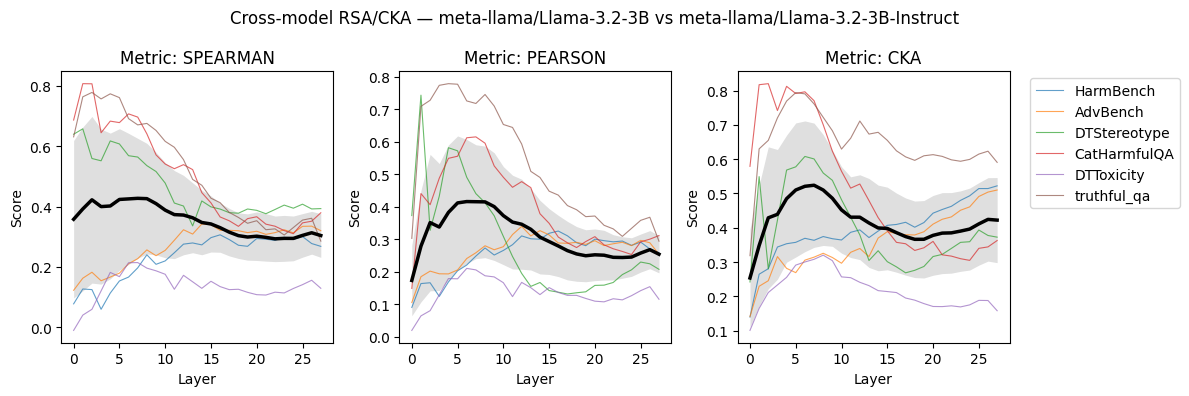

('google/gemma-2-2b', 'google/gemma-2-2b-it') | model.layers.0 | Harmbench | spearman: 0.0917
('google/gemma-2-2b', 'google/gemma-2-2b-it') | model.layers.0 | Harmbench | pearson: 0.0961
('google/gemma-2-2b', 'google/gemma-2-2b-it') | model.layers.0 | Harmbench | cka: 0.1395
('google/gemma-2-2b', 'google/gemma-2-2b-it') | model.layers.0 | walledai/AdvBench | spearman: 0.0894
('google/gemma-2-2b', 'google/gemma-2-2b-it') | model.layers.0 | walledai/AdvBench | pearson: 0.0872
('google/gemma-2-2b', 'google/gemma-2-2b-it') | model.layers.0 | walledai/AdvBench | cka: 0.1402
('google/gemma-2-2b', 'google/gemma-2-2b-it') | model.layers.0 | walledai/DTStereotype | spearman: 0.3954
('google/gemma-2-2b', 'google/gemma-2-2b-it') | model.layers.0 | walledai/DTStereotype | pearson: 0.0746
('google/gemma-2-2b', 'google/gemma-2-2b-it') | model.layers.0 | walledai/DTStereotype | cka: 0.0993
('google/gemma-2-2b', 'google/gemma-2-2b-it') | model.layers.0 | walledai/CatHarmfulQA | spearman: 0.4512
('goog

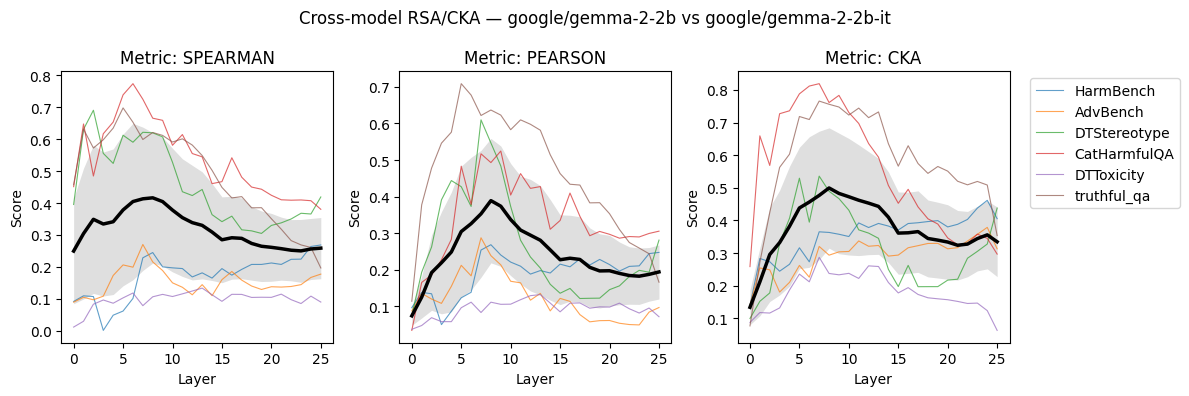

('Qwen/Qwen2.5-3B', 'Qwen/Qwen2.5-3B-Instruct') | model.layers.0 | Harmbench | spearman: 0.0993
('Qwen/Qwen2.5-3B', 'Qwen/Qwen2.5-3B-Instruct') | model.layers.0 | Harmbench | pearson: 0.1596
('Qwen/Qwen2.5-3B', 'Qwen/Qwen2.5-3B-Instruct') | model.layers.0 | Harmbench | cka: 0.3229
('Qwen/Qwen2.5-3B', 'Qwen/Qwen2.5-3B-Instruct') | model.layers.0 | walledai/AdvBench | spearman: 0.1185
('Qwen/Qwen2.5-3B', 'Qwen/Qwen2.5-3B-Instruct') | model.layers.0 | walledai/AdvBench | pearson: 0.1731
('Qwen/Qwen2.5-3B', 'Qwen/Qwen2.5-3B-Instruct') | model.layers.0 | walledai/AdvBench | cka: 0.2539
('Qwen/Qwen2.5-3B', 'Qwen/Qwen2.5-3B-Instruct') | model.layers.0 | walledai/DTStereotype | spearman: 0.6514
('Qwen/Qwen2.5-3B', 'Qwen/Qwen2.5-3B-Instruct') | model.layers.0 | walledai/DTStereotype | pearson: 0.4528
('Qwen/Qwen2.5-3B', 'Qwen/Qwen2.5-3B-Instruct') | model.layers.0 | walledai/DTStereotype | cka: 0.2320
('Qwen/Qwen2.5-3B', 'Qwen/Qwen2.5-3B-Instruct') | model.layers.0 | walledai/CatHarmfulQA | spe

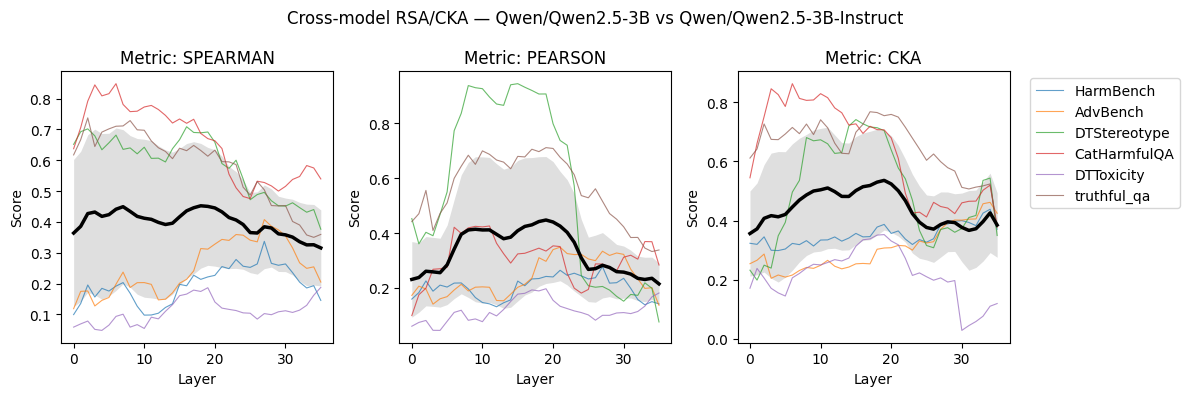

('allenai/OLMo-2-0425-1B', 'allenai/OLMo-2-0425-1B-Instruct') | model.layers.0 | Harmbench | spearman: 0.0399
('allenai/OLMo-2-0425-1B', 'allenai/OLMo-2-0425-1B-Instruct') | model.layers.0 | Harmbench | pearson: 0.0557
('allenai/OLMo-2-0425-1B', 'allenai/OLMo-2-0425-1B-Instruct') | model.layers.0 | Harmbench | cka: 0.1029
('allenai/OLMo-2-0425-1B', 'allenai/OLMo-2-0425-1B-Instruct') | model.layers.0 | walledai/AdvBench | spearman: 0.1091
('allenai/OLMo-2-0425-1B', 'allenai/OLMo-2-0425-1B-Instruct') | model.layers.0 | walledai/AdvBench | pearson: 0.0626
('allenai/OLMo-2-0425-1B', 'allenai/OLMo-2-0425-1B-Instruct') | model.layers.0 | walledai/AdvBench | cka: 0.0809
('allenai/OLMo-2-0425-1B', 'allenai/OLMo-2-0425-1B-Instruct') | model.layers.0 | walledai/DTStereotype | spearman: 0.7304
('allenai/OLMo-2-0425-1B', 'allenai/OLMo-2-0425-1B-Instruct') | model.layers.0 | walledai/DTStereotype | pearson: 0.9885
('allenai/OLMo-2-0425-1B', 'allenai/OLMo-2-0425-1B-Instruct') | model.layers.0 | wall

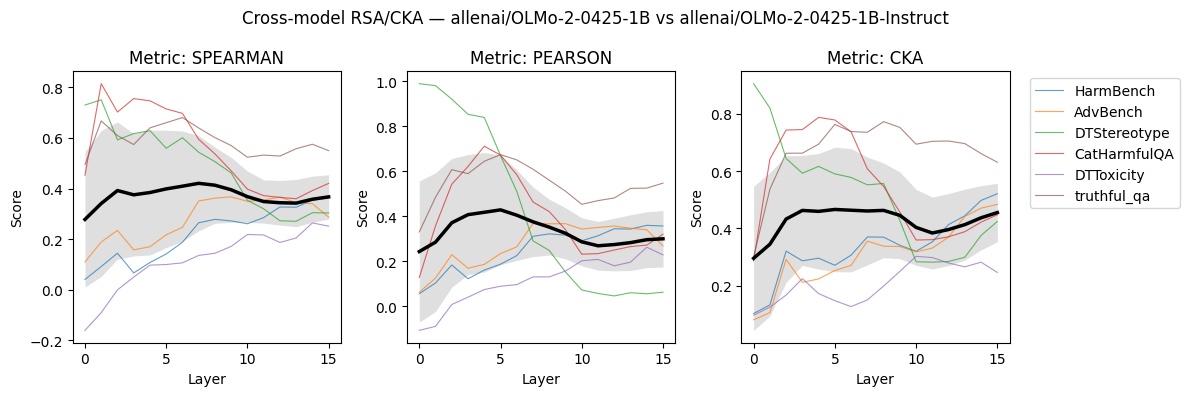

In [47]:
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from scipy.stats import spearmanr, pearsonr
import numpy as np
import matplotlib.pyplot as plt
import re

models = [( "meta-llama/Llama-3.2-3B", "meta-llama/Llama-3.2-3B-Instruct"), ("google/gemma-2-2b", "google/gemma-2-2b-it"),
          ("Qwen/Qwen2.5-3B", "Qwen/Qwen2.5-3B-Instruct"), ("allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct")]

def rdm(X):
    return 1 - cosine_similarity(X)

def rsa_similarity_from_X(X1, X2, method='spearman'):
    R1, R2 = rdm(X1), rdm(X2)
    i, j = np.triu_indices_from(R1, k=1)
    v1, v2 = R1[i, j], R2[i, j]
    if method == 'spearman':
        corr, _ = spearmanr(v1, v2)
    elif method == 'pearson':
        corr, _ = pearsonr(v1, v2)
    else:
        raise ValueError(f"Unknown method {method}")
    return corr

def numpy_cka(X, Y):
    X = X - X.mean(0, keepdims=True)
    Y = Y - Y.mean(0, keepdims=True)
    Kx, Ky = linear_kernel(X), linear_kernel(Y)
    hsic = np.sum(Kx * Ky)
    denom = np.sqrt(np.sum(Kx * Kx) * np.sum(Ky * Ky))
    return hsic / denom

for pair in models:
    model_base, model_it = pair
    safe_base = re.sub(r'[\\/*?:"<>|]', "_", model_base)
    safe_it = re.sub(r'[\\/*?:"<>|]', "_", model_it)
    # Load A
    X_1b, v1b = load_harmbench(model_base, output_dir)
    layer_names = sorted(list(X_1b.keys()), key=lambda x: int(x.split('.')[-1]))
    # Load B
    X_1i, v1i = load_harmbench(model_it, output_dir)
    steering_vector_a = torch.load(os.path.join(f"{output_dir}/{safe_base}", "steering_vectors.pt"))
    steering_vector_b = torch.load(os.path.join(f"{output_dir}/{safe_it}", "steering_vectors.pt"))


    res = {}
    res_all = {}
    for layer in layer_names:
        if layer not in X_1i:
            print(f"[WARN] Layer {layer} missing in {model_it}; skipping.")
            continue
        cos_sim = {'spearman': [], 'pearson': [], 'cka': []}
        # Build combined matrices in the SAME dataset order for both models
        X_b = X_1b[layer].float().numpy() #@ steering_vector_a[layer]['toxic'].float().numpy()
        X_i = X_1i[layer].float().numpy() #@ steering_vector_b[layer]['toxic'].float().numpy()
        for method in ['spearman', 'pearson', 'cka']:
            if method == 'cka':
                sim = numpy_cka(X_b, X_i)
            else:
                sim = rsa_similarity_from_X(X_b, X_i, method=method)
            cos_sim[method].append(sim)
            print(f"{pair} | {layer} | Harmbench | {method}: {sim:.4f}")

        # Other datasets — must be appended in the same order for both models
        for ds in datasets_list:
            X_2b, _ = load_datasets(model_base, ds, output_dir)
            X_2i, _ = load_datasets(model_it, ds, output_dir)

            if layer not in X_2b or layer not in X_2i:
                print(f"[WARN] {layer} missing for {ds}; skipping that dataset for this layer.")
                continue
            # (Optional) assert equal n:
            if X_2b[layer].shape[0] != X_2i[layer].shape[0]:
                print(f"[WARN] Sample count mismatch for {ds} at {layer}; skipping.")
                continue
            X_b = X_2b[layer].float().numpy() #@ steering_vector_a[layer]['toxic'].float().numpy()
            X_i = X_2i[layer].float().numpy() #@ steering_vector_b[layer]['toxic'].float().numpy()
            for method in ['spearman', 'pearson', 'cka']:
                if method == 'cka':
                    sim = numpy_cka(X_b, X_i)
                else:
                    sim = rsa_similarity_from_X(X_b, X_i, method=method)
                cos_sim[method].append(sim)
                print(f"{pair} | {layer} | {ds} | {method}: {sim:.4f}")

        

        res[layer] = {}
        res_all[layer] = {}
        for method in ['spearman', 'pearson', 'cka']:
            sim = np.mean(cos_sim[method])
            res[layer][method] = sim
            res_all[layer][method] = cos_sim[method]
            print(f"{pair} | {layer} | {method}: {sim:.4f}")

    # ---- Plot per pair ----
    plot_layers = [ln for ln in layer_names if ln in res]
    x = [int(l.split('.')[-1]) for l in plot_layers]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True)
    axes = axes.flatten()
    datasets = ["HarmBench"] + [data.split('/')[-1] for data in datasets_list]
    for i, metric in enumerate(['spearman', 'pearson', 'cka']):
        ax = axes[i]
        # y = [res[l][metric] for l in plot_layers]
        # ax.plot(x, y, marker='o')
        # ax.set_title(metric.upper())
        # ax.set_xlabel("Layer index")
        # ax.set_ylabel("Similarity")
        # ax.grid(alpha=0.3)
        
        plt.sca(ax)
        plot_metric_ribbon(res_all, plot_layers, metric=metric, color="grey", #["tab:blue","tab:orange","tab:green","tab:purple"][i],
                        smooth=2, ci="sem", show_individual=True, dataset_list=datasets)
                
        plt.xlabel("Layer")
        plt.ylabel("Score")
        plt.title(f"Metric: {metric.upper()}")
        # plt.xticks([int(l.split('.')[-1]) for l in layers], rotation=90)

    plt.legend(datasets, bbox_to_anchor=(1.05, 1), loc='upper left')
    fig.suptitle(f"Cross-model RSA/CKA — {model_base} vs {model_it}")
    fig.tight_layout()
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_base}_vs_{safe_it}_cross_model_rsa_cka.png",
                dpi=300, bbox_inches='tight')
    plt.show()


['reference.layer.0', 'reference.layer.1', 'reference.layer.2', 'reference.layer.3', 'reference.layer.4', 'reference.layer.5', 'reference.layer.6', 'reference.layer.7', 'reference.layer.8', 'reference.layer.9', 'reference.layer.10', 'reference.layer.11', 'reference.layer.12', 'reference.layer.13', 'reference.layer.14', 'reference.layer.15', 'reference.layer.16', 'reference.layer.17', 'reference.layer.18', 'reference.layer.19']
['reference.layer.0', 'reference.layer.1', 'reference.layer.2', 'reference.layer.3', 'reference.layer.4', 'reference.layer.5', 'reference.layer.6', 'reference.layer.7', 'reference.layer.8', 'reference.layer.9', 'reference.layer.10', 'reference.layer.11', 'reference.layer.12', 'reference.layer.13', 'reference.layer.14', 'reference.layer.15', 'reference.layer.16', 'reference.layer.17', 'reference.layer.18', 'reference.layer.19']
['reference.layer.0', 'reference.layer.1', 'reference.layer.2', 'reference.layer.3', 'reference.layer.4', 'reference.layer.5', 'reference.

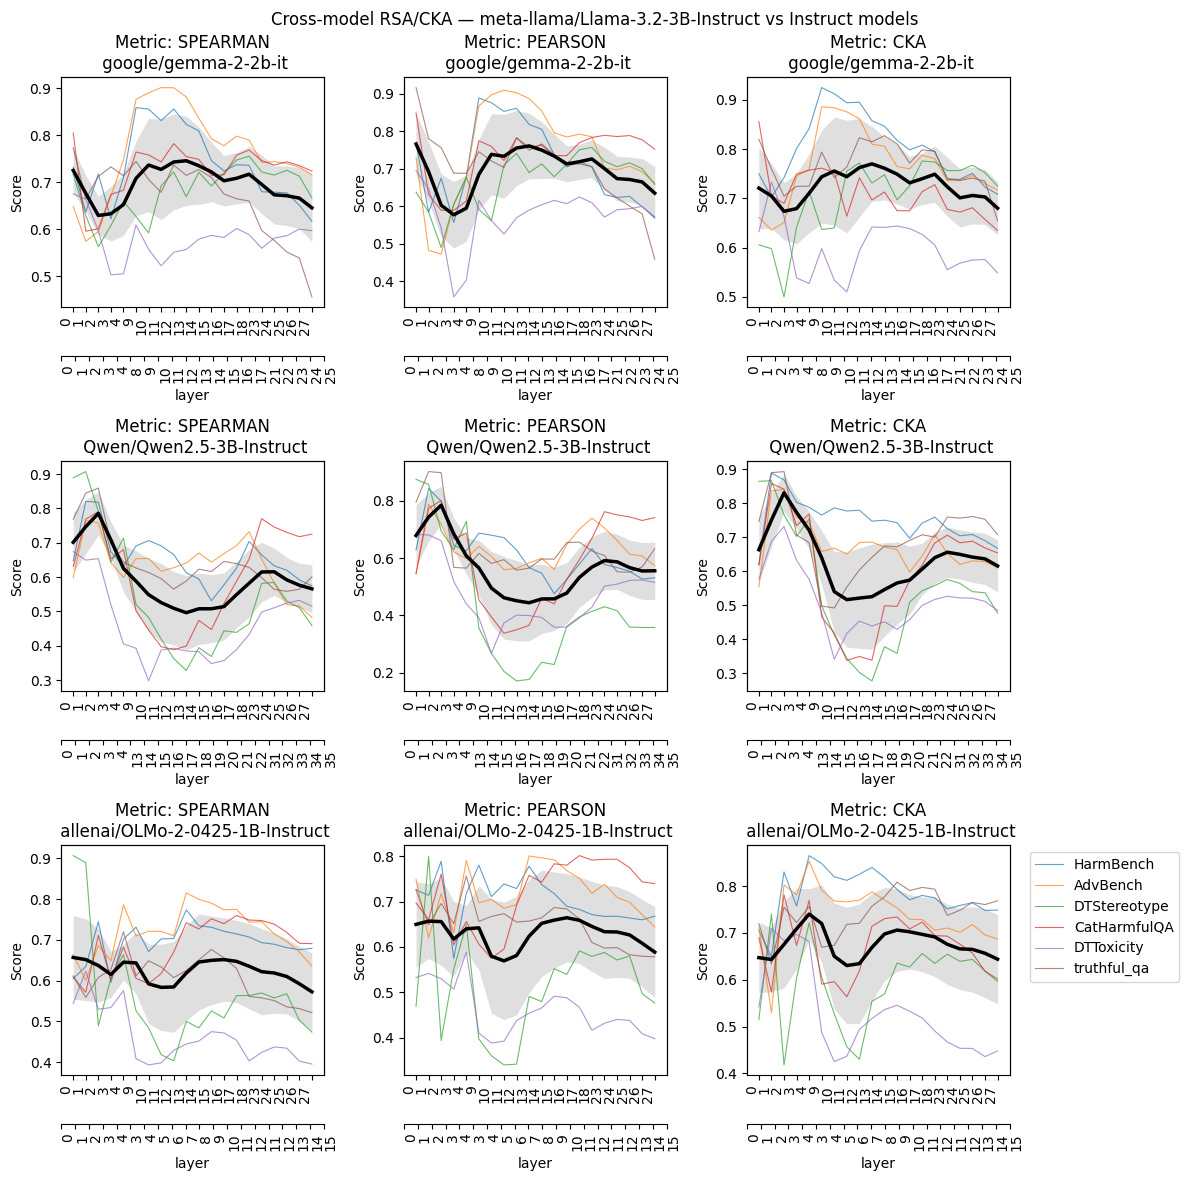

['reference.layer.0', 'reference.layer.1', 'reference.layer.2', 'reference.layer.3', 'reference.layer.4', 'reference.layer.5', 'reference.layer.6', 'reference.layer.7', 'reference.layer.8', 'reference.layer.9', 'reference.layer.10', 'reference.layer.11', 'reference.layer.12', 'reference.layer.13', 'reference.layer.14', 'reference.layer.15', 'reference.layer.16', 'reference.layer.17', 'reference.layer.18', 'reference.layer.19']
['reference.layer.0', 'reference.layer.1', 'reference.layer.2', 'reference.layer.3', 'reference.layer.4', 'reference.layer.5', 'reference.layer.6', 'reference.layer.7', 'reference.layer.8', 'reference.layer.9', 'reference.layer.10', 'reference.layer.11', 'reference.layer.12', 'reference.layer.13', 'reference.layer.14', 'reference.layer.15', 'reference.layer.16', 'reference.layer.17', 'reference.layer.18', 'reference.layer.19']
['reference.layer.0', 'reference.layer.1', 'reference.layer.2', 'reference.layer.3', 'reference.layer.4', 'reference.layer.5', 'reference.

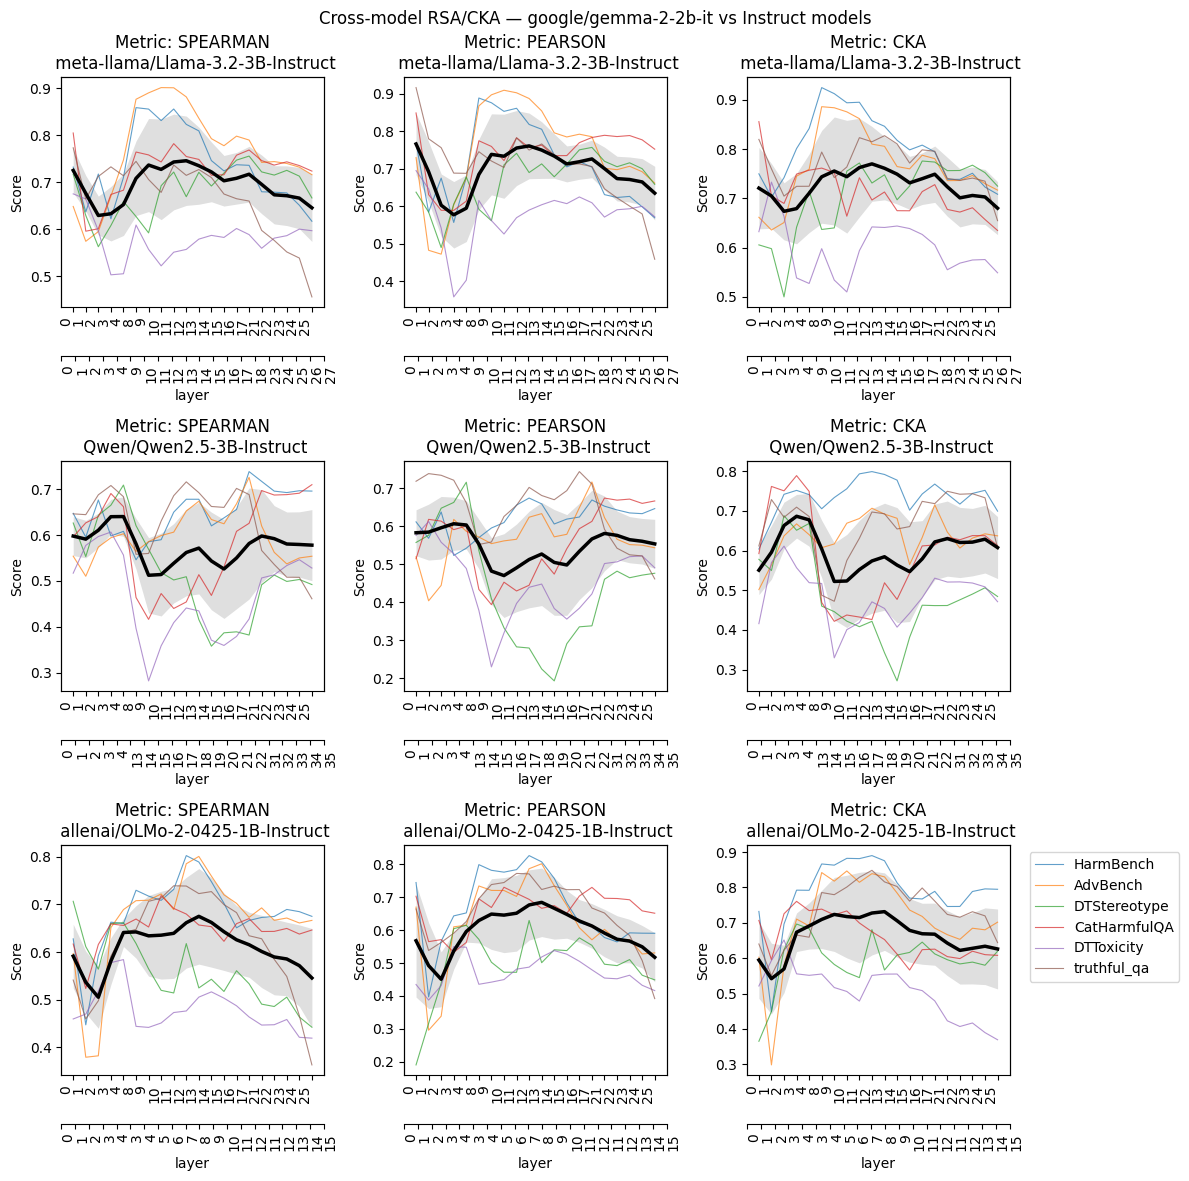

['reference.layer.0', 'reference.layer.1', 'reference.layer.2', 'reference.layer.3', 'reference.layer.4', 'reference.layer.5', 'reference.layer.6', 'reference.layer.7', 'reference.layer.8', 'reference.layer.9', 'reference.layer.10', 'reference.layer.11', 'reference.layer.12', 'reference.layer.13', 'reference.layer.14', 'reference.layer.15', 'reference.layer.16', 'reference.layer.17', 'reference.layer.18', 'reference.layer.19']
['reference.layer.0', 'reference.layer.1', 'reference.layer.2', 'reference.layer.3', 'reference.layer.4', 'reference.layer.5', 'reference.layer.6', 'reference.layer.7', 'reference.layer.8', 'reference.layer.9', 'reference.layer.10', 'reference.layer.11', 'reference.layer.12', 'reference.layer.13', 'reference.layer.14', 'reference.layer.15', 'reference.layer.16', 'reference.layer.17', 'reference.layer.18', 'reference.layer.19']
['reference.layer.0', 'reference.layer.1', 'reference.layer.2', 'reference.layer.3', 'reference.layer.4', 'reference.layer.5', 'reference.

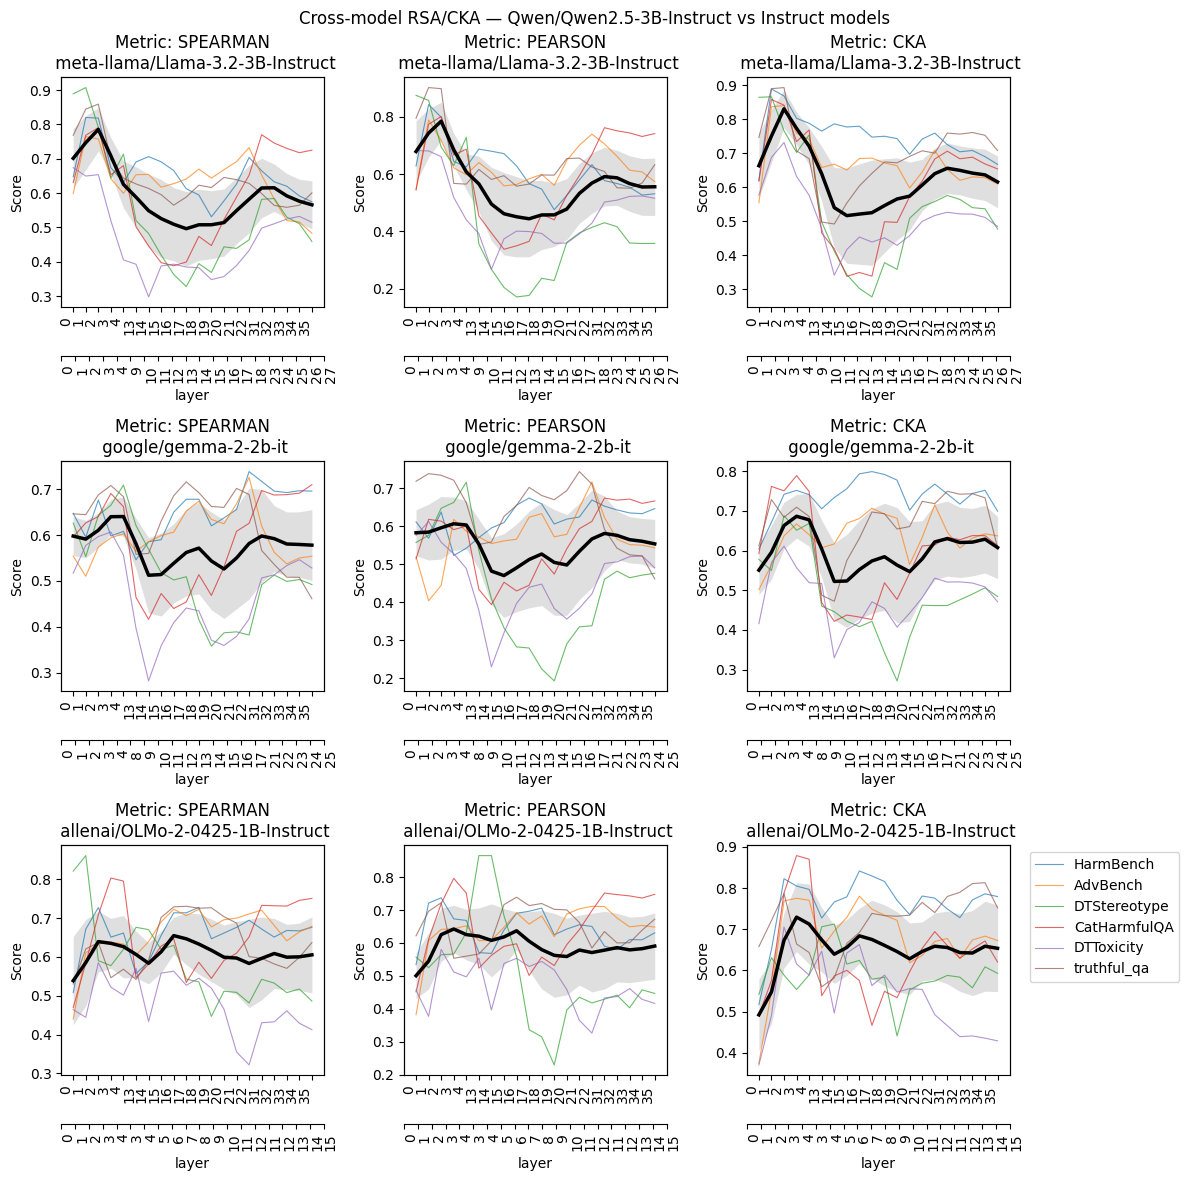

['reference.layer.0', 'reference.layer.1', 'reference.layer.2', 'reference.layer.3', 'reference.layer.4', 'reference.layer.5', 'reference.layer.6', 'reference.layer.7', 'reference.layer.8', 'reference.layer.9', 'reference.layer.10', 'reference.layer.11', 'reference.layer.12', 'reference.layer.13', 'reference.layer.14', 'reference.layer.15', 'reference.layer.16', 'reference.layer.17', 'reference.layer.18', 'reference.layer.19']
['reference.layer.0', 'reference.layer.1', 'reference.layer.2', 'reference.layer.3', 'reference.layer.4', 'reference.layer.5', 'reference.layer.6', 'reference.layer.7', 'reference.layer.8', 'reference.layer.9', 'reference.layer.10', 'reference.layer.11', 'reference.layer.12', 'reference.layer.13', 'reference.layer.14', 'reference.layer.15', 'reference.layer.16', 'reference.layer.17', 'reference.layer.18', 'reference.layer.19']
['reference.layer.0', 'reference.layer.1', 'reference.layer.2', 'reference.layer.3', 'reference.layer.4', 'reference.layer.5', 'reference.

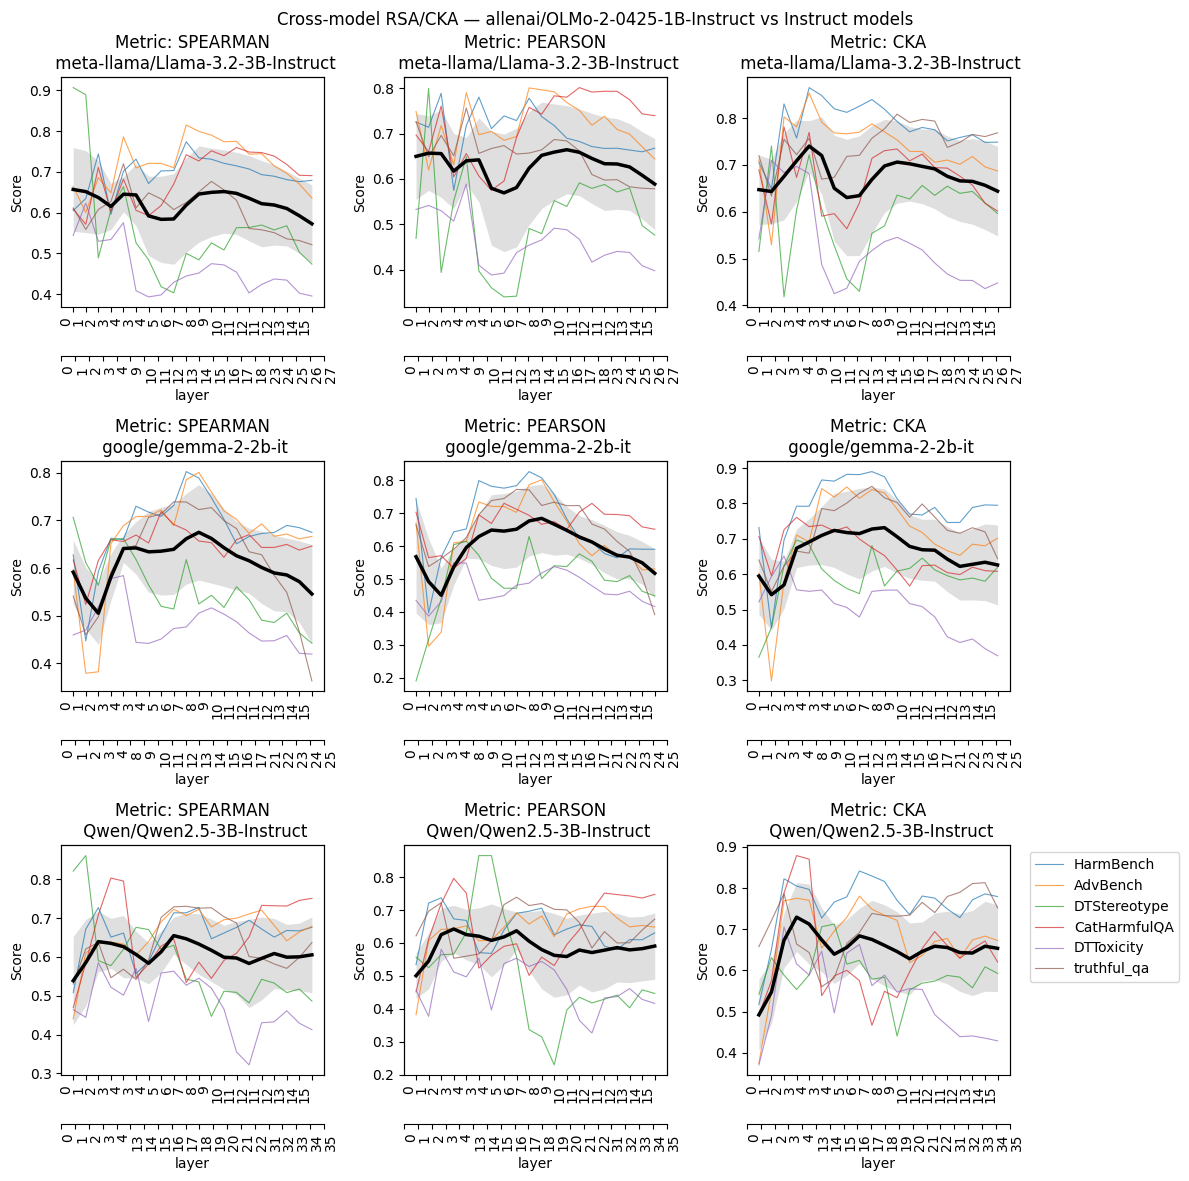

In [56]:
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from scipy.stats import spearmanr, pearsonr
import numpy as np
import matplotlib.pyplot as plt
import re

models = ["meta-llama/Llama-3.2-3B-Instruct", "google/gemma-2-2b-it", "Qwen/Qwen2.5-3B-Instruct", "allenai/OLMo-2-0425-1B-Instruct"]

def rdm(X):
    return 1 - cosine_similarity(X)

def rsa_similarity_from_X(X1, X2, method='spearman'):
    R1, R2 = rdm(X1), rdm(X2)
    i, j = np.triu_indices_from(R1, k=1)
    v1, v2 = R1[i, j], R2[i, j]
    if method == 'spearman':
        corr, _ = spearmanr(v1, v2)
    elif method == 'pearson':
        corr, _ = pearsonr(v1, v2)
    else:
        raise ValueError(f"Unknown method {method}")
    return corr

def numpy_cka(X, Y):
    X = X - X.mean(0, keepdims=True)
    Y = Y - Y.mean(0, keepdims=True)
    Kx, Ky = linear_kernel(X), linear_kernel(Y)
    hsic = np.sum(Kx * Ky)
    denom = np.sqrt(np.sum(Kx * Kx) * np.sum(Ky * Ky))
    return hsic / denom

X_all = {}
for model in models:
    X_all[model] = []
    X_1, v1 = load_harmbench(model, output_dir)
    safe_model = re.sub(r'[\\/*?:"<>|]', "_", model)
    X_all[model].append(X_1)

    for ds in datasets_list:
        X_2, _ = load_datasets(model, ds, output_dir)
        X_all[model].append(X_2)


    res = {}
    res_all = {}
for model1 in models:
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))#, sharex=True)
    plot_idx = 0
    for model2 in models:
        res = {}
        if model1 == model2:
            continue
        
        pair = (model1, model2)
        layers_1 = sorted(list(X_all[model1][0].keys()), key=lambda x: int(x.split('.')[-1]))
        layers_2 = sorted(list(X_all[model2][0].keys()), key=lambda x: int(x.split('.')[-1]))
       
        middle_1 = len(layers_1) // 2
        middle_2 = len(layers_2) // 2
        
        choose_layers_2 = layers_2[:5] + layers_2[middle_2 - 5:middle_2 + 5] + layers_2[-5:]
        choose_layers_1 = layers_1[:5] + layers_1[middle_1 - 5:middle_1 + 5] + layers_1[-5:]
        # middle_layers1 = [layers_1[i] for i in np.linspace(6, len(layers_1) - 6, 10, dtype=int)]
        # middle_layers2 = [layers_2[i] for i in np.linspace(6, len(layers_2) - 6, 10, dtype=int)]
        # choose_layers_2 = layers_2[:5] + middle_layers2 + layers_2[-5:]
        # choose_layers_1 = layers_1[:5] + middle_layers1 + layers_1[-5:]
        for i, (layer1, layer2) in enumerate(zip(choose_layers_1, choose_layers_2)):
            res[f'reference.layer.{i}'] = {}
            cos = {}
            for method in ['spearman', 'pearson', 'cka']:
                res[f'reference.layer.{i}'][method] = []
                cos[method] = []
            for d, data in enumerate(['w/Harmbench'] + datasets_list):
                X_1 = X_all[model1][d][layer1]
                X_2 = X_all[model2][d][layer2]
                for method in ['spearman', 'pearson', 'cka']:
                    if method == 'cka':
                        sim = numpy_cka(X_1.float().numpy(), X_2.float().numpy())
                    else:
                        sim = rsa_similarity_from_X(X_1.float().numpy(), X_2.float().numpy(), method=method)
                    cos[method].append(sim)


            for method in ['spearman', 'pearson', 'cka']:

                res[f'reference.layer.{i}'][method] = cos[method]
                    # print(f"{pair} | Layer1: {layer1} | Layer2: {layer2} | {data} | {method}: {sim:.4f}")
        # ---- Plot per pair ----
        plot_layers = list(res.keys())
        # x = [int(l.split('.')[-1]) for l in plot_layers]
        print(plot_layers)
        # fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True)
        # axes = axes.flatten()
        datasets = ["HarmBench"] + [data.split('/')[-1] for data in datasets_list]
        for i, metric in enumerate(['spearman', 'pearson', 'cka']):
            ax = axes[plot_idx][i]
            
            plt.sca(ax)
            plot_metric_ribbon(res, plot_layers, metric=metric, color="grey", #["tab:blue","tab:orange","tab:green","tab:purple"][i],
                            smooth=2, ci="sem", show_individual=True, dataset_list=datasets)
                    
            # plt.xlabel("Layer")
            plt.ylabel("Score")
            plt.title(f"Metric: {metric.upper()}\n {model2}")
            ax.set_xticks(range(len(plot_layers)))
            ax.set_xticklabels([int(layer.split('.')[-1]) for layer in choose_layers_1], rotation=90, ha="right")

            ax2= ax.twiny()
            
            ax2.xaxis.set_ticks_position('bottom')
            ax2.xaxis.set_label_position('bottom')
            ax2.spines['bottom'].set_position(('outward', 35))  # shift downward
            ax2.set_xticks(range(len(plot_layers)))
            ax2.set_xticklabels([int(layer.split('.')[-1]) for layer in choose_layers_2], rotation=90, ha="left")
            # plt.xticks([int(l.split('.')[-1]) for l in layers], rotation=90)
            ax2.set_xlabel('layer')
        plot_idx += 1
    ax.legend(datasets, bbox_to_anchor=(1.05, 1), loc='upper left')
    fig.suptitle(f"Cross-model RSA/CKA — {model1} vs Instruct models")
    fig.tight_layout()
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model1)
    plt.savefig(f"/home/fe/purelku/Desktop/Master_thesis/results_RSA/{safe_model_name}_vs_instruct_models_rsa_cka.png",
                dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

